# NB03d — Evaporative Kinetics: Pan Evaporation Analysis

Analyzes pan evaporation (15°C, 672 h) kinetic curves and connects them to
compositional data from rotary evaporation (80°C) through the shared variable:
mass loss percentage.

**Key question:** Does the volatile fraction (GC-MS, Experiment 1) predict the
pan evaporation rate (mass loss, Experiment 2)?

**Depends on:** NB00, NB01, NB03c4
**Produces:** kinetic parameters (IER, ML_max, t_half), cross-experiment validation, ~9 figures

## PART 0 — Setup

In [1]:
import sys, warnings, shutil
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path
from scipy.stats import spearmanr
from scipy.interpolate import interp1d
from scipy.optimize import curve_fit
from IPython.display import display, Image
warnings.filterwarnings('ignore')

sys.path.insert(0, str(Path('..') / 'notebooks'))
from utils import get_conn, OILTYPE_COLORS, STAGE_COLORS, setup_figure_style, FIG_ROOT

setup_figure_style()
import matplotlib as _mpl
_mpl.rcParams['font.family'] = 'DejaVu Sans'

FIG_DIR = FIG_ROOT / 'nb03d'
if FIG_DIR.exists():
    shutil.rmtree(FIG_DIR)
FIG_DIR.mkdir(parents=True, exist_ok=True)

OIL_TYPES_ML = ['crude', 'bitumen_blend', 'refined', 'synthetic']
ENDPOINT = 672.0
MARGIN = 2.0

ALKANE_BP = {
    'n-C8': 126, 'n-C9': 151, 'n-C10': 174, 'n-C11': 196, 'n-C12': 216,
    'n-C13': 235, 'n-C14': 254, 'n-C15': 271, 'n-C16': 287, 'n-C17': 302,
    'n-C18': 316, 'n-C19': 330, 'n-C20': 343, 'n-C21': 356, 'n-C22': 369,
    'n-C23': 380, 'n-C24': 391, 'n-C25': 402, 'n-C26': 412, 'n-C27': 422,
    'n-C28': 431, 'n-C29': 440, 'n-C30': 450, 'n-C31': 458, 'n-C32': 466,
    'n-C33': 474, 'n-C34': 481, 'n-C35': 490,
}
ISOPRENOID_BP = {'Pristane': 296, 'Phytane': 322}
PAH_BP = {
    'C0-Naphthalene': 218, 'C0-Fluorene': 295,
    'C0-Dibenzothiophene': 332, 'C0-Phenanthrene': 340, 'C0-Chrysene': 448,
}
BIOMARKER_BP = {'Hopane (H30)': 450, 'C27 sterane': 440, 'Ts': 430}
ALL_BP = {}
ALL_BP.update(ALKANE_BP)
ALL_BP.update(ISOPRENOID_BP)
ALL_BP.update(PAH_BP)
ALL_BP.update(BIOMARKER_BP)

BP_THRESHOLD = 250

print(f'Setup OK | FIG_DIR: {FIG_DIR}')
print(f'BP reference: {len(ALL_BP)} compounds')

Setup OK | FIG_DIR: C:\Users\leogr\Documents\Data Science\TCC\figures\nb03d
BP reference: 38 compounds


## PART 1 — Pan Evaporation Curve Characterization

In [2]:
# C01 -- Load pan evaporation data (analysis oils only)
with get_conn() as conn:
    df_pan = pd.read_sql("""
        SELECT p.oil_id, o.oil_name, o.oil_type,
               p.time_hours, p.mass_loss_pct, p.temperature_c
        FROM pan_evaporation p
        JOIN oils o ON p.oil_id = o.oil_id
        WHERE o.include_in_analysis = 1
        ORDER BY p.oil_id, p.time_hours
    """, conn)

n_oils = df_pan['oil_id'].nunique()
n_times = df_pan['time_hours'].nunique()
print(f'Pan evaporation data: {n_oils} oils, {n_times} time points')
print(f'Time range: {df_pan["time_hours"].min():.2f} - {df_pan["time_hours"].max():.0f} hours')
print(f'Temperature: {df_pan["temperature_c"].unique()} \u00b0C')
print(f'\nOils by type:')
print(df_pan.groupby('oil_type')['oil_id'].nunique().to_string())

Pan evaporation data: 41 oils, 29 time points
Time range: 0.00 - 672 hours
Temperature: [15.] °C

Oils by type:
oil_type
bitumen_blend     4
crude            34
refined           1
synthetic         2


In [3]:
# B4 -- Identify oils without pan evaporation data
with get_conn() as conn:
    all_analysis = pd.read_sql("""
        SELECT oil_id, oil_name, oil_type FROM oils
        WHERE include_in_analysis = 1
    """, conn)
    pan_oils = pd.read_sql("SELECT DISTINCT oil_id FROM pan_evaporation", conn)

missing = all_analysis[~all_analysis['oil_id'].isin(pan_oils['oil_id'])]
print(f'Oils in analysis WITHOUT pan evaporation data ({len(missing)}):')
print(missing[['oil_name', 'oil_type']].to_string(index=False))

# ML-qualified subset (complete W0-W3)
with get_conn() as conn:
    ml_oils = pd.read_sql("""
        SELECT o.oil_id, o.oil_name, o.oil_type
        FROM oils o
        WHERE o.include_in_analysis = 1
          AND (SELECT COUNT(DISTINCT m.stage_code)
               FROM measurements m WHERE m.oil_id = o.oil_id) = 4
    """, conn)

ml_with_pan = ml_oils[ml_oils['oil_id'].isin(pan_oils['oil_id'])]
ml_without_pan = ml_oils[~ml_oils['oil_id'].isin(pan_oils['oil_id'])]

print(f'\nML-qualified oils (complete W0-W3): {len(ml_oils)}')
print(f'  With pan evaporation data: {len(ml_with_pan)}')
print(f'  Without pan evaporation data: {len(ml_without_pan)}')
if len(ml_without_pan) > 0:
    for _, row in ml_without_pan.iterrows():
        print(f'    {row["oil_name"]} ({row["oil_type"]})')

Oils in analysis WITHOUT pan evaporation data (21):
                      oil_name      oil_type
  Alberta Sweet Mixed Blend #4 bitumen_blend
 Cold Lake Blend Summer [2014] bitumen_blend
 Cold Lake Blend Winter [2015] bitumen_blend
 Cold Lake Blend Winter [2018] bitumen_blend
 Cold Lake Blend Winter [2019] bitumen_blend
                      Endicott         crude
                 Hebron [2018]         crude
               Hibernia [2018]         crude
            Marine Diesel (B5)       refined
          Marine Diesel [2018]       refined
      Marine Diesel-Burnaby BC       refined
Marine Diesel-Corporal Teather       refined
    Marine Diesel-Hurst Marina       refined
  Marine Diesel-Ile Saint Ours       refined
               Mars TLP [2000]         crude
                   Maya [2004]         crude
                 Platform Elly         crude
            Prudhoe Bay [2004]         crude
                  Sockeye Sour         crude
             Terra Nova [2018]         crude
   

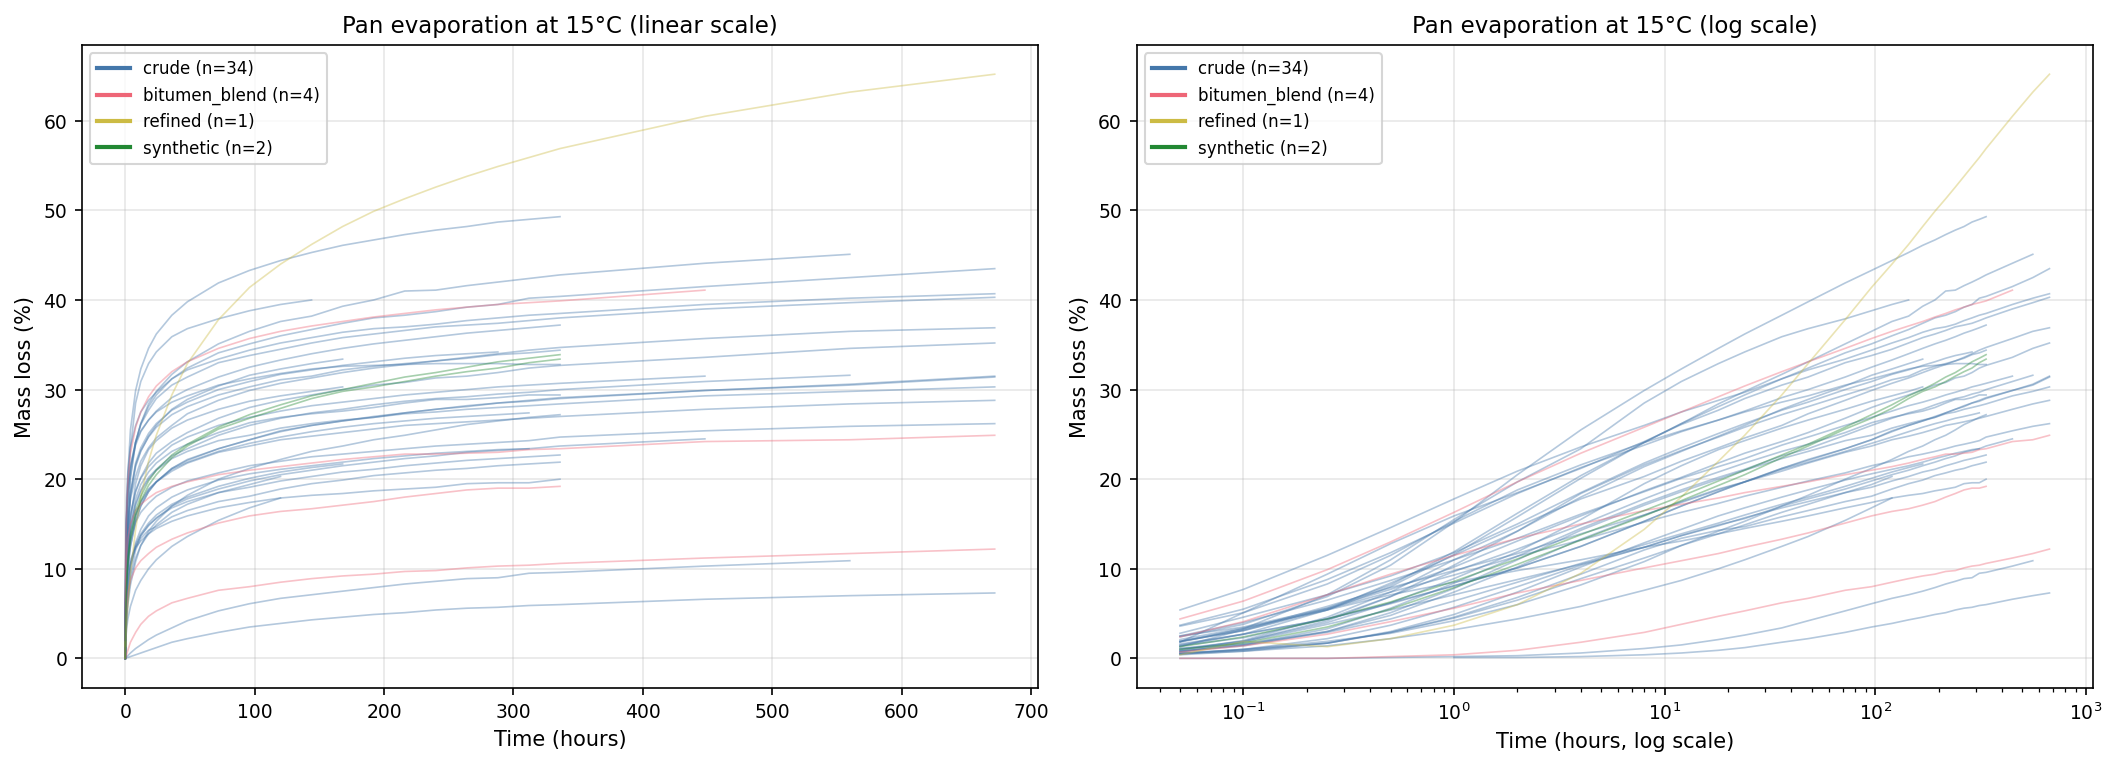

In [4]:
# F01 -- Pan evaporation curves by oil type
fig, axes = plt.subplots(1, 2, figsize=(14, 5), constrained_layout=True)

ax = axes[0]
for otype in OIL_TYPES_ML:
    sub = df_pan[df_pan['oil_type'] == otype]
    for oid in sub['oil_id'].unique():
        od = sub[sub['oil_id'] == oid].sort_values('time_hours')
        ax.plot(od['time_hours'], od['mass_loss_pct'],
                color=OILTYPE_COLORS[otype], alpha=0.4, linewidth=0.8)
for otype in OIL_TYPES_ML:
    n = df_pan[df_pan['oil_type'] == otype]['oil_id'].nunique()
    if n > 0:
        ax.plot([], [], color=OILTYPE_COLORS[otype], linewidth=2, label=f'{otype} (n={n})')
ax.set_xlabel('Time (hours)'); ax.set_ylabel('Mass loss (%)')
ax.set_title('Pan evaporation at 15\u00b0C (linear scale)')
ax.legend(fontsize=8); ax.grid(alpha=0.3)

ax = axes[1]
for otype in OIL_TYPES_ML:
    sub = df_pan[df_pan['oil_type'] == otype]
    for oid in sub['oil_id'].unique():
        od = sub[sub['oil_id'] == oid].sort_values('time_hours')
        mask = od['time_hours'] > 0
        ax.plot(od.loc[mask, 'time_hours'], od.loc[mask, 'mass_loss_pct'],
                color=OILTYPE_COLORS[otype], alpha=0.4, linewidth=0.8)
for otype in OIL_TYPES_ML:
    n = df_pan[df_pan['oil_type'] == otype]['oil_id'].nunique()
    if n > 0:
        ax.plot([], [], color=OILTYPE_COLORS[otype], linewidth=2, label=f'{otype} (n={n})')
ax.set_xscale('log')
ax.set_xlabel('Time (hours, log scale)'); ax.set_ylabel('Mass loss (%)')
ax.set_title('Pan evaporation at 15\u00b0C (log scale)')
ax.legend(fontsize=8); ax.grid(alpha=0.3)

fig_path = FIG_DIR / 'F01_pan_evaporation_curves.png'
plt.savefig(fig_path, dpi=150, bbox_inches='tight')
plt.close('all')
display(Image(filename=str(fig_path)))

In [5]:
# C03 -- Compute kinetic parameters per oil
# Note: 'initial_rate' is the linear slope of first 3 points = early evaporation rate (EER),
# not the true instantaneous initial rate. See B7 for log coefficient comparison.
kinetic_params = []
for oil_id in df_pan['oil_id'].unique():
    oil_data = df_pan[df_pan['oil_id'] == oil_id].sort_values('time_hours')
    oil_name = oil_data['oil_name'].iloc[0]
    oil_type = oil_data['oil_type'].iloc[0]
    times = oil_data['time_hours'].values
    ml = oil_data['mass_loss_pct'].values

    early = oil_data[oil_data['time_hours'] > 0].head(3)
    if len(early) >= 2:
        ier = np.polyfit(early['time_hours'].values, early['mass_loss_pct'].values, 1)[0]
    else:
        ier = np.nan

    ml_max = ml[-1]
    target = ml_max / 2
    if target > 0 and np.any(ml >= target):
        t_half = float(interp1d(ml, times, bounds_error=False, fill_value=np.nan)(target))
    else:
        t_half = np.nan

    kinetic_params.append({
        'oil_id': oil_id, 'oil_name': oil_name, 'oil_type': oil_type,
        'initial_rate': ier, 'max_mass_loss': ml_max, 'half_time': t_half,
    })

df_kinetics = pd.DataFrame(kinetic_params)
print(f'Kinetic parameters for {len(df_kinetics)} oils\n')
print(df_kinetics.groupby('oil_type').agg(
    n=('oil_id', 'count'),
    IER_mean=('initial_rate', 'mean'), IER_std=('initial_rate', 'std'),
    MLmax_mean=('max_mass_loss', 'mean'), MLmax_std=('max_mass_loss', 'std'),
    thalf_mean=('half_time', 'mean'), thalf_std=('half_time', 'std'),
).round(2).to_string())

Kinetic parameters for 41 oils

                n  IER_mean  IER_std  MLmax_mean  MLmax_std  thalf_mean  thalf_std
oil_type                                                                          
bitumen_blend   4     14.73    12.18       24.35      12.32       11.32      15.72
crude          34     15.00     8.02       29.98       9.23       10.32      20.93
refined         1      2.54      NaN       65.20        NaN       46.97        NaN
synthetic       2     13.69     1.85       33.65       0.35        9.50       0.54


## PART 2 — Volatile Fraction vs Evaporation Rate (Cross-Experiment Validation)

In [6]:
# C04 -- Compute volatile fraction from W0 compositional data
with get_conn() as conn:
    df_w0 = pd.read_sql("""
        SELECT m.oil_id, c.compound_name, m.value_raw
        FROM measurements m
        JOIN compounds c ON m.compound_id = c.compound_id
        JOIN oils o ON m.oil_id = o.oil_id
        WHERE o.include_in_analysis = 1
          AND m.stage_code = 'W0'
          AND m.value_raw > 0
    """, conn)

df_w0['bp'] = df_w0['compound_name'].map(ALL_BP)
df_w0_bp = df_w0.dropna(subset=['bp'])

print(f'W0 measurements with BP mapping: {len(df_w0_bp)} '
      f'({df_w0_bp["compound_name"].nunique()} compounds, '
      f'{df_w0_bp["oil_id"].nunique()} oils)')

volatile = df_w0_bp[df_w0_bp['bp'] < BP_THRESHOLD].groupby('oil_id')['value_raw'].sum()
total = df_w0_bp.groupby('oil_id')['value_raw'].sum()
frac_volatile = pd.DataFrame({'oil_id': total.index,
                               'frac_volatile_pct': (volatile / total * 100).values}).dropna()

print(f'\nVolatile fraction (BP < {BP_THRESHOLD}\u00b0C) computed for {len(frac_volatile)} oils')
print(f'Range: {frac_volatile["frac_volatile_pct"].min():.1f}% - {frac_volatile["frac_volatile_pct"].max():.1f}%')

W0 measurements with BP mapping: 2026 (36 compounds, 59 oils)

Volatile fraction (BP < 250°C) computed for 59 oils
Range: 2.9% - 69.5%


In [7]:
# C05 -- Merge kinetic params with volatile fraction, compute correlations
df_merged = df_kinetics.merge(frac_volatile, on='oil_id').dropna(subset=['frac_volatile_pct'])
print(f'Merged dataset: {len(df_merged)} oils with both kinetic and compositional data\n')

rho_ier, p_ier = spearmanr(df_merged['frac_volatile_pct'], df_merged['initial_rate'])
rho_ml, p_ml = spearmanr(df_merged['frac_volatile_pct'], df_merged['max_mass_loss'])

print(f'Volatile fraction vs IER:    \u03c1 = {rho_ier:.3f}, p = {p_ier:.2e}')
print(f'Volatile fraction vs ML_max: \u03c1 = {rho_ml:.3f}, p = {p_ml:.2e}')

Merged dataset: 39 oils with both kinetic and compositional data

Volatile fraction vs IER:    ρ = -0.009, p = 9.55e-01
Volatile fraction vs ML_max: ρ = 0.018, p = 9.16e-01


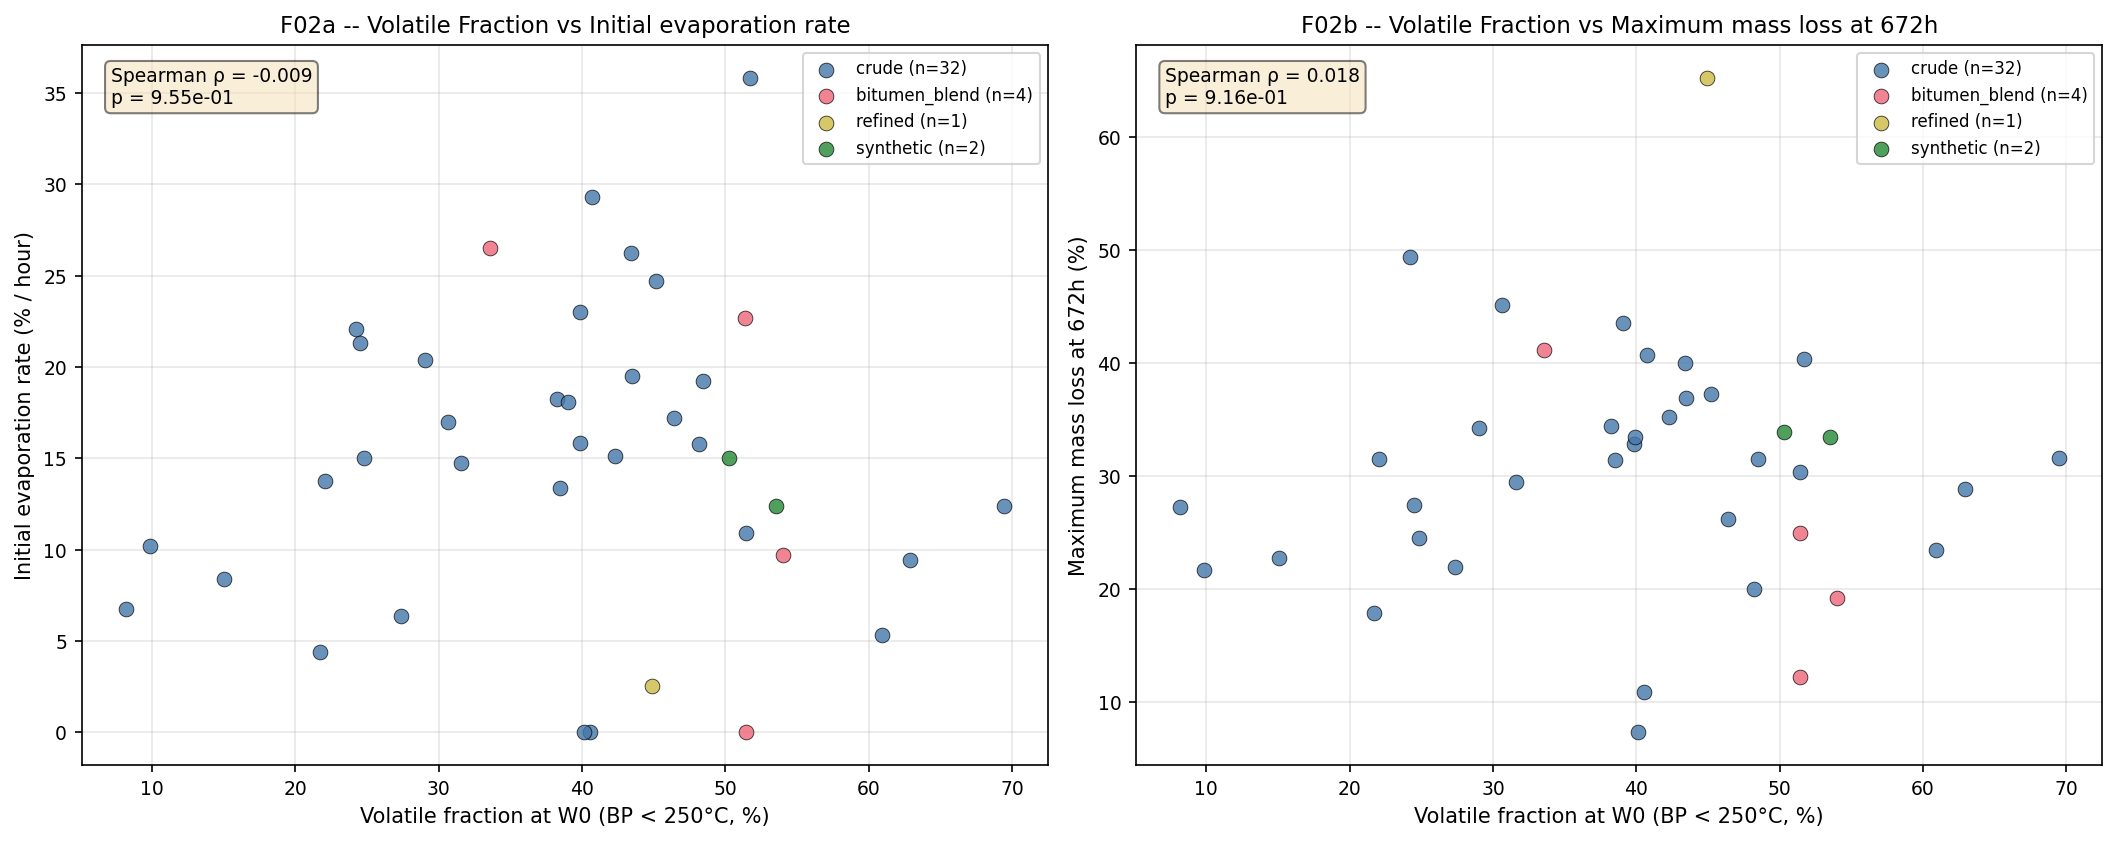

In [8]:
# F02 -- Volatile fraction vs kinetics scatter
fig, axes = plt.subplots(1, 2, figsize=(14, 5.5), constrained_layout=True)
for ax_i, (col, ylabel, rho_val, p_val) in enumerate([
    ('initial_rate', 'Initial evaporation rate (% / hour)', rho_ier, p_ier),
    ('max_mass_loss', 'Maximum mass loss at 672h (%)', rho_ml, p_ml),
]):
    ax = axes[ax_i]
    for otype in OIL_TYPES_ML:
        sub = df_merged[df_merged['oil_type'] == otype]
        if len(sub) == 0: continue
        ax.scatter(sub['frac_volatile_pct'], sub[col],
                  c=OILTYPE_COLORS[otype], s=50, edgecolors='k', linewidth=0.4,
                  label=f'{otype} (n={len(sub)})', alpha=0.8, zorder=5)
    ax.set_xlabel(f'Volatile fraction at W0 (BP < {BP_THRESHOLD}\u00b0C, %)')
    ax.set_ylabel(ylabel)
    lab = 'a' if ax_i == 0 else 'b'
    ax.set_title(f'F02{lab} -- Volatile Fraction vs {ylabel.split("(")[0].strip()}')
    ax.text(0.03, 0.97, f'Spearman \u03c1 = {rho_val:.3f}\np = {p_val:.2e}',
            transform=ax.transAxes, fontsize=9, verticalalignment='top',
            bbox=dict(boxstyle='round', facecolor='wheat', alpha=0.5))
    ax.legend(fontsize=8); ax.grid(alpha=0.3)
fig_path = FIG_DIR / 'F02_volatile_fraction_vs_kinetics.png'
plt.savefig(fig_path, dpi=150, bbox_inches='tight')
plt.close('all')
display(Image(filename=str(fig_path)))

### Interpretation: Why GC-MS Volatile Fraction Does Not Predict Evaporation Rate

The null correlation (ρ ≈ 0) between GC-MS volatile fraction and pan evaporation rate reveals a fundamental decoupling between molecular fingerprinting and bulk physical behavior.

GC-MS semi-quantitative analysis identifies individual compounds — the "resolved peaks" in the chromatogram. For crude oils in the ECCC dataset, resolved peaks represent only 15–34% of the total oil mass (NB03b: UCM fraction 0.665–0.845). The remaining 66–85% is the Unresolved Complex Mixture (UCM) — thousands of co-eluting compounds that cannot be individually identified.

Pan evaporation measures TOTAL mass loss — every molecule that evaporates, whether individually resolved by GC-MS or hidden in the UCM. Two oils with identical resolved volatile fractions can have very different total volatile fractions if their UCMs differ in composition.

This explains why API gravity correlates with ML_max but molecular fingerprinting does not: API gravity is a bulk measurement reflecting the TOTAL composition, including the UCM.

**Implication for the ML model:** The XGBoost model trains on resolved compound concentrations (the 92 GC-MS measurements). These measurements capture compositional detail but not the UCM — which controls the bulk evaporation rate. The model predicts weathering STAGE (an ordinal category defined by total mass loss), yet its features represent only 15–34% of the mass that drives the stage transitions. The model succeeds (MAE = 0.499) because the resolved compounds undergo systematic, predictable changes correlated with total mass loss — even though they don't directly represent the total volatile inventory.

**Implication for forensic practice:** An analyst using GC-MS fingerprints can identify the oil and assess its weathering state, but cannot predict how fast the oil will continue evaporating. Physical property measurements (API gravity, viscosity) remain necessary for evaporation rate estimation.

## PART 2B — UCM and Lightest Compounds

UCM fraction vs evaporation kinetics (n=27):
  UCM vs IER:    ρ = -0.280, p = 1.58e-01
  UCM vs ML_max: ρ = -0.422, p = 2.83e-02

UCM fraction correlates with evaporation -- oils with more UCM evaporate SLOWER.


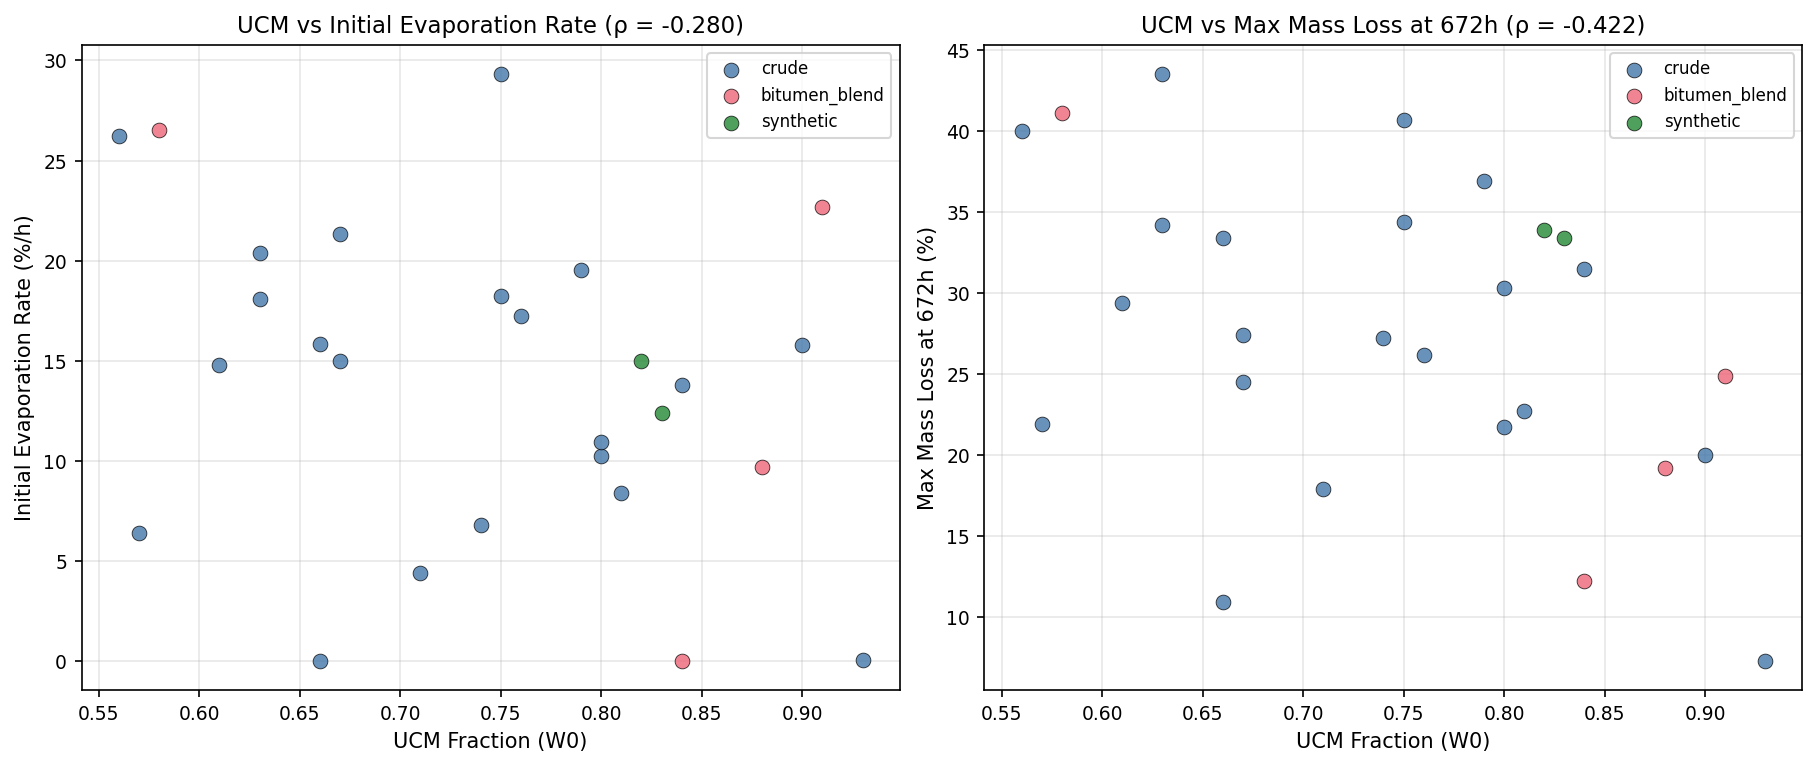

In [9]:
# B1 -- UCM fraction vs evaporation rate
with get_conn() as conn:
    df_ucm = pd.read_sql("""
        SELECT sp.oil_id, sp.value AS ucm_fraction
        FROM sample_properties sp
        JOIN oils o ON sp.oil_id = o.oil_id
        WHERE sp.property_name = 'ucm_fraction'
          AND sp.stage_code = 'W0'
          AND o.include_in_analysis = 1
    """, conn)

df_ucm_kin = df_ucm.set_index('oil_id').join(
    df_kinetics.set_index('oil_id')[['initial_rate', 'max_mass_loss', 'oil_type']]
).dropna(subset=['initial_rate', 'ucm_fraction'])

rho_ucm_ier, p_ucm_ier = spearmanr(df_ucm_kin['ucm_fraction'], df_ucm_kin['initial_rate'])
rho_ucm_ml, p_ucm_ml = spearmanr(df_ucm_kin['ucm_fraction'], df_ucm_kin['max_mass_loss'])

print(f'UCM fraction vs evaporation kinetics (n={len(df_ucm_kin)}):')
print(f'  UCM vs IER:    \u03c1 = {rho_ucm_ier:.3f}, p = {p_ucm_ier:.2e}')
print(f'  UCM vs ML_max: \u03c1 = {rho_ucm_ml:.3f}, p = {p_ucm_ml:.2e}')
print()
if abs(rho_ucm_ml) > 0.3:
    direction = 'SLOWER' if rho_ucm_ml < 0 else 'FASTER'
    print(f'UCM fraction correlates with evaporation -- oils with more UCM evaporate {direction}.')
else:
    print('UCM fraction does not predict evaporation rate either.')
    print('UCM composition is variable -- some oils have light UCM, others heavy.')

fig, axes = plt.subplots(1, 2, figsize=(12, 5), constrained_layout=True)
for ax_i, (col, ylabel, rho_val) in enumerate([
    ('initial_rate', 'Initial Evaporation Rate (%/h)', rho_ucm_ier),
    ('max_mass_loss', 'Max Mass Loss at 672h (%)', rho_ucm_ml),
]):
    ax = axes[ax_i]
    for otype in OIL_TYPES_ML:
        sub = df_ucm_kin[df_ucm_kin['oil_type'] == otype]
        if len(sub) == 0: continue
        ax.scatter(sub['ucm_fraction'], sub[col],
                  c=OILTYPE_COLORS[otype], s=50, edgecolors='k', linewidth=0.4,
                  label=otype, alpha=0.8, zorder=5)
    ax.set_xlabel('UCM Fraction (W0)'); ax.set_ylabel(ylabel)
    ax.set_title(f'UCM vs {ylabel.split("(")[0].strip()} (\u03c1 = {rho_val:.3f})')
    ax.legend(fontsize=8); ax.grid(alpha=0.3)
fig_path = FIG_DIR / 'F06_ucm_vs_evaporation.png'
plt.savefig(fig_path, dpi=150, bbox_inches='tight')
plt.close('all')
display(Image(filename=str(fig_path)))

In [10]:
# B2 -- IER vs lightest individual compounds
light_compounds = ['n-C9', 'n-C10', 'n-C11', 'n-C12']
print('Correlation of individual light compounds with kinetic parameters:\n')
print(f'{"Compound":12s} {"vs IER rho":>10s} {"p":>10s} {"vs MLmax rho":>14s} {"p":>10s} {"n":>5s}')
print('-' * 65)
with get_conn() as conn:
    for comp_name in light_compounds:
        df_comp = pd.read_sql("""
            SELECT m.oil_id, m.value_raw
            FROM measurements m
            JOIN compounds c ON m.compound_id = c.compound_id
            JOIN oils o ON m.oil_id = o.oil_id
            WHERE c.compound_name LIKE ?
              AND m.stage_code = 'W0'
              AND o.include_in_analysis = 1
              AND m.value_raw > 0
        """, conn, params=(f'{comp_name}%',))
        merged_comp = df_comp.set_index('oil_id').join(
            df_kinetics.set_index('oil_id')[['initial_rate', 'max_mass_loss']]
        ).dropna()
        if len(merged_comp) > 10:
            r_ier, p_i = spearmanr(merged_comp['value_raw'], merged_comp['initial_rate'])
            r_ml, p_m = spearmanr(merged_comp['value_raw'], merged_comp['max_mass_loss'])
            print(f'{comp_name:12s} {r_ier:+10.3f} {p_i:10.3f} {r_ml:+14.3f} {p_m:10.3f} {len(merged_comp):5d}')
        else:
            print(f'{comp_name:12s}  insufficient data (n={len(merged_comp)})')

Correlation of individual light compounds with kinetic parameters:

Compound     vs IER rho          p   vs MLmax rho          p     n
-----------------------------------------------------------------
n-C9             +0.407      0.011         +0.419      0.009    38
n-C10            +0.390      0.016         +0.513      0.001    38
n-C11            +0.375      0.020         +0.519      0.001    38
n-C12            +0.362      0.026         +0.501      0.001    38


## PART 3 — Physical Properties vs Kinetics

In [11]:
# C06 -- API gravity vs evaporation rate
with get_conn() as conn:
    df_api = pd.read_sql("""
        SELECT oil_id, value AS api_gravity
        FROM sample_properties
        WHERE property_name = 'api_gravity'
          AND stage_code = 'W0'
    """, conn)

df_api_merged = df_kinetics.merge(df_api, on='oil_id').dropna(subset=['api_gravity'])
rho_api, p_api = spearmanr(df_api_merged['api_gravity'], df_api_merged['initial_rate'])
rho_api_ml, p_api_ml = spearmanr(df_api_merged['api_gravity'], df_api_merged['max_mass_loss'])
print(f'API gravity vs IER:    \u03c1 = {rho_api:.3f}, p = {p_api:.2e} (n={len(df_api_merged)})')
print(f'API gravity vs ML_max: \u03c1 = {rho_api_ml:.3f}, p = {p_api_ml:.2e}')

API gravity vs IER:    ρ = 0.477, p = 2.14e-03 (n=39)
API gravity vs ML_max: ρ = 0.875, p = 3.45e-13


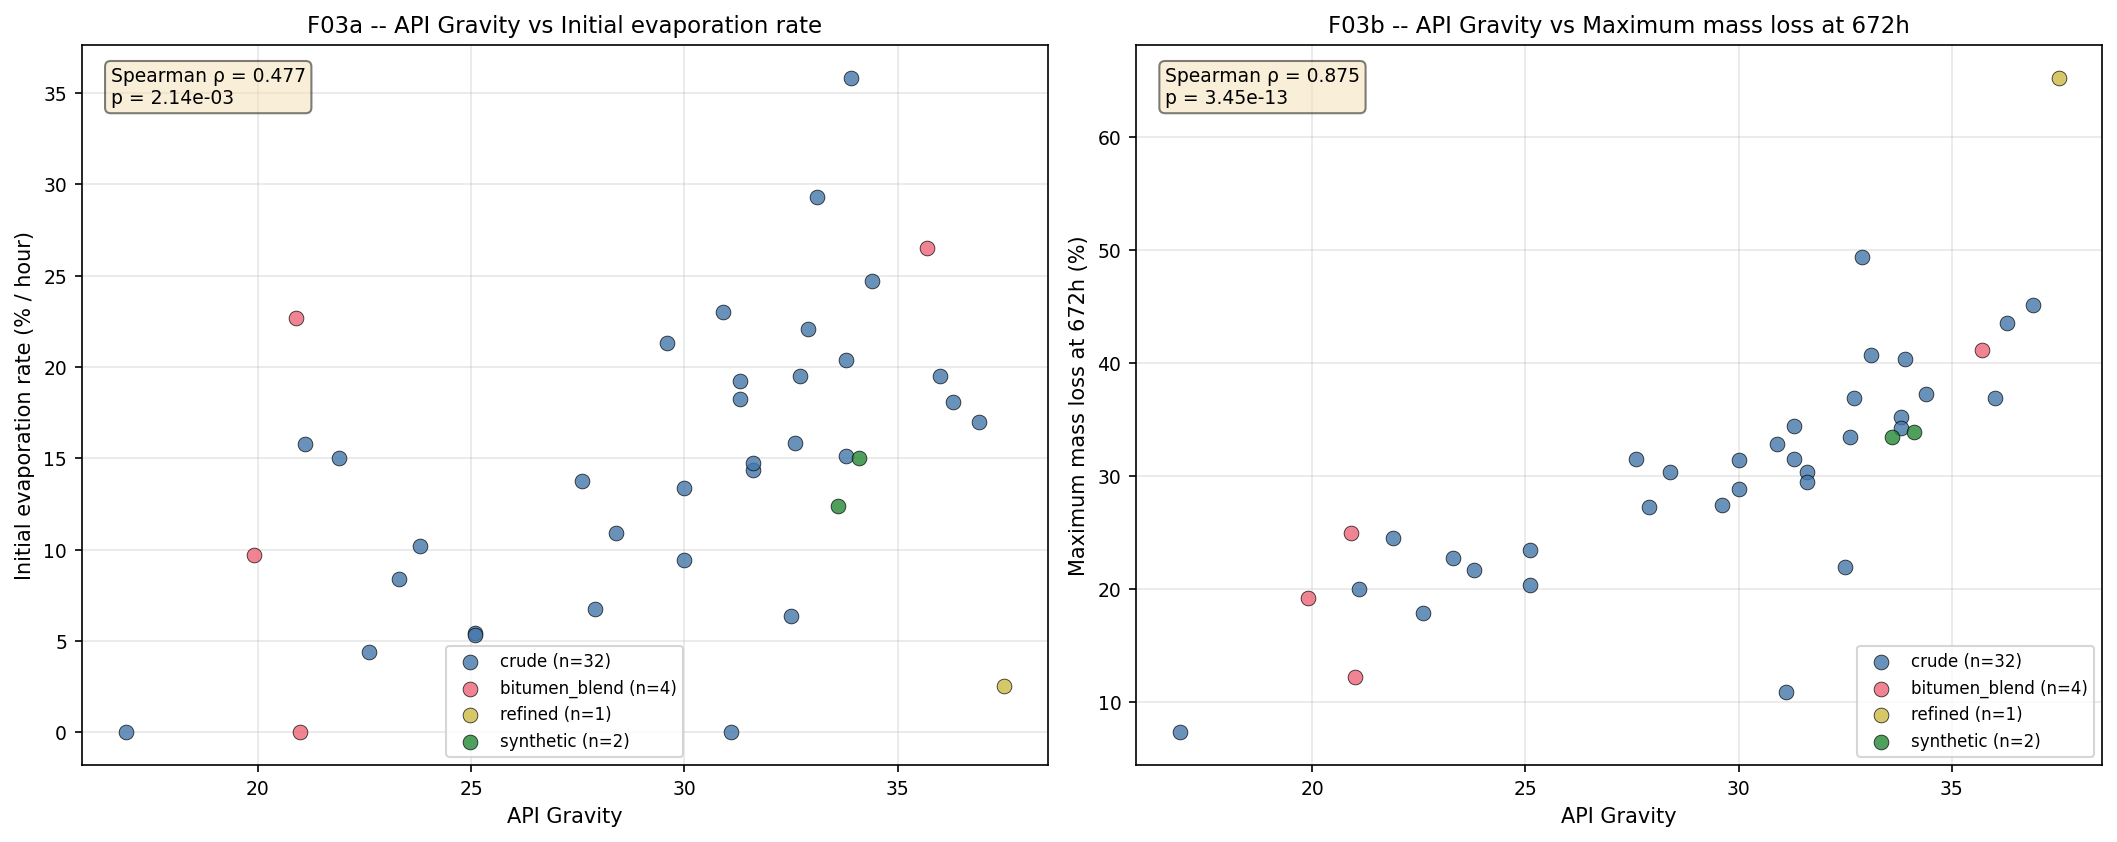

In [12]:
# F03 -- API gravity vs kinetic parameters
fig, axes = plt.subplots(1, 2, figsize=(14, 5.5), constrained_layout=True)
for ax_i, (col, ylabel, rho_val, p_val) in enumerate([
    ('initial_rate', 'Initial evaporation rate (% / hour)', rho_api, p_api),
    ('max_mass_loss', 'Maximum mass loss at 672h (%)', rho_api_ml, p_api_ml),
]):
    ax = axes[ax_i]
    for otype in OIL_TYPES_ML:
        sub = df_api_merged[df_api_merged['oil_type'] == otype]
        if len(sub) == 0: continue
        ax.scatter(sub['api_gravity'], sub[col],
                  c=OILTYPE_COLORS[otype], s=50, edgecolors='k', linewidth=0.4,
                  label=f'{otype} (n={len(sub)})', alpha=0.8, zorder=5)
    ax.set_xlabel('API Gravity'); ax.set_ylabel(ylabel)
    lab = 'a' if ax_i == 0 else 'b'
    ax.set_title(f'F03{lab} -- API Gravity vs {ylabel.split("(")[0].strip()}')
    ax.text(0.03, 0.97, f'Spearman \u03c1 = {rho_val:.3f}\np = {p_val:.2e}',
            transform=ax.transAxes, fontsize=9, verticalalignment='top',
            bbox=dict(boxstyle='round', facecolor='wheat', alpha=0.5))
    ax.legend(fontsize=8); ax.grid(alpha=0.3)
fig_path = FIG_DIR / 'F03_api_gravity_vs_kinetics.png'
plt.savefig(fig_path, dpi=150, bbox_inches='tight')
plt.close('all')
display(Image(filename=str(fig_path)))

## PART 4 — Time-to-Stage at 15°C

In [13]:
# C07 -- Load pre-computed time-to-stage (Fix 1: corrected 672h boundary)
with get_conn() as conn:
    df_kin_stage = pd.read_sql("""
        SELECT k.oil_id, o.oil_name, o.oil_type,
               k.stage_code, k.time_hours, k.mass_loss_pct
        FROM oil_weathering_kinetics k
        JOIN oils o ON k.oil_id = o.oil_id
        WHERE o.include_in_analysis = 1
          AND k.stage_code IN ('W1', 'W2', 'W3')
        ORDER BY k.oil_id, k.stage_code
    """, conn)

print(f'Time-to-stage data: {df_kin_stage["oil_id"].nunique()} oils\n')
for stage in ['W1', 'W2', 'W3']:
    sub = df_kin_stage[df_kin_stage['stage_code'] == stage]
    n_reach = (sub['time_hours'] < (ENDPOINT - MARGIN)).sum()
    n_total = len(sub)
    n_boundary = ((sub['time_hours'] >= (ENDPOINT - MARGIN)) &
                  (sub['time_hours'] <= ENDPOINT)).sum()
    print(f'{stage}: {n_reach}/{n_total} reach within 672h '
          f'({n_boundary} at experiment endpoint)')

print(f'\nW3 reachability by oil type:')
w3 = df_kin_stage[df_kin_stage['stage_code'] == 'W3']
for otype in OIL_TYPES_ML:
    sub = w3[w3['oil_type'] == otype]
    if len(sub) == 0: continue
    n_reach = (sub['time_hours'] < (ENDPOINT - MARGIN)).sum()
    print(f'  {otype}: {n_reach}/{len(sub)} reach W3')

boundary = df_kin_stage[df_kin_stage['time_hours'] >= (ENDPOINT - MARGIN)]
if len(boundary) > 0:
    print(f'\nOils at experiment endpoint:')
    for _, row in boundary.iterrows():
        print(f'  {row["oil_name"]}: {row["stage_code"]} at {row["time_hours"]:.0f}h '
              f'({row["mass_loss_pct"]:.1f}% mass loss)')

Time-to-stage data: 41 oils

W1: 41/41 reach within 672h (0 at experiment endpoint)
W2: 39/41 reach within 672h (2 at experiment endpoint)
W3: 38/41 reach within 672h (3 at experiment endpoint)

W3 reachability by oil type:
  crude: 33/34 reach W3
  bitumen_blend: 2/4 reach W3
  refined: 1/1 reach W3
  synthetic: 2/2 reach W3

Oils at experiment endpoint:
  Access West Blend Winter: W3 at 672h (25.3% mass loss)
  Cold Lake Blend Winter [2013]: W2 at 672h (15.8% mass loss)
  Cold Lake Blend Winter [2013]: W3 at 672h (23.6% mass loss)
  Husky Energy SGS: W2 at 672h (9.9% mass loss)
  Husky Energy SGS: W3 at 672h (14.8% mass loss)


**Note on discrepancy with NB03:** NB03 reported 33/45 oils not reaching W3 at 15°C (using 45 oils including those without pan evaporation data and strict interpolation of mass loss targets). NB03d uses 41 oils with pan evaporation data and the pre-computed `oil_weathering_kinetics` table. Additionally, oils with time_hours = 672.0 (the experiment endpoint) are now correctly flagged as NOT having reached the target stage. The qualitative conclusion is identical: most oils require weeks to months to reach advanced weathering stages at ambient temperature.

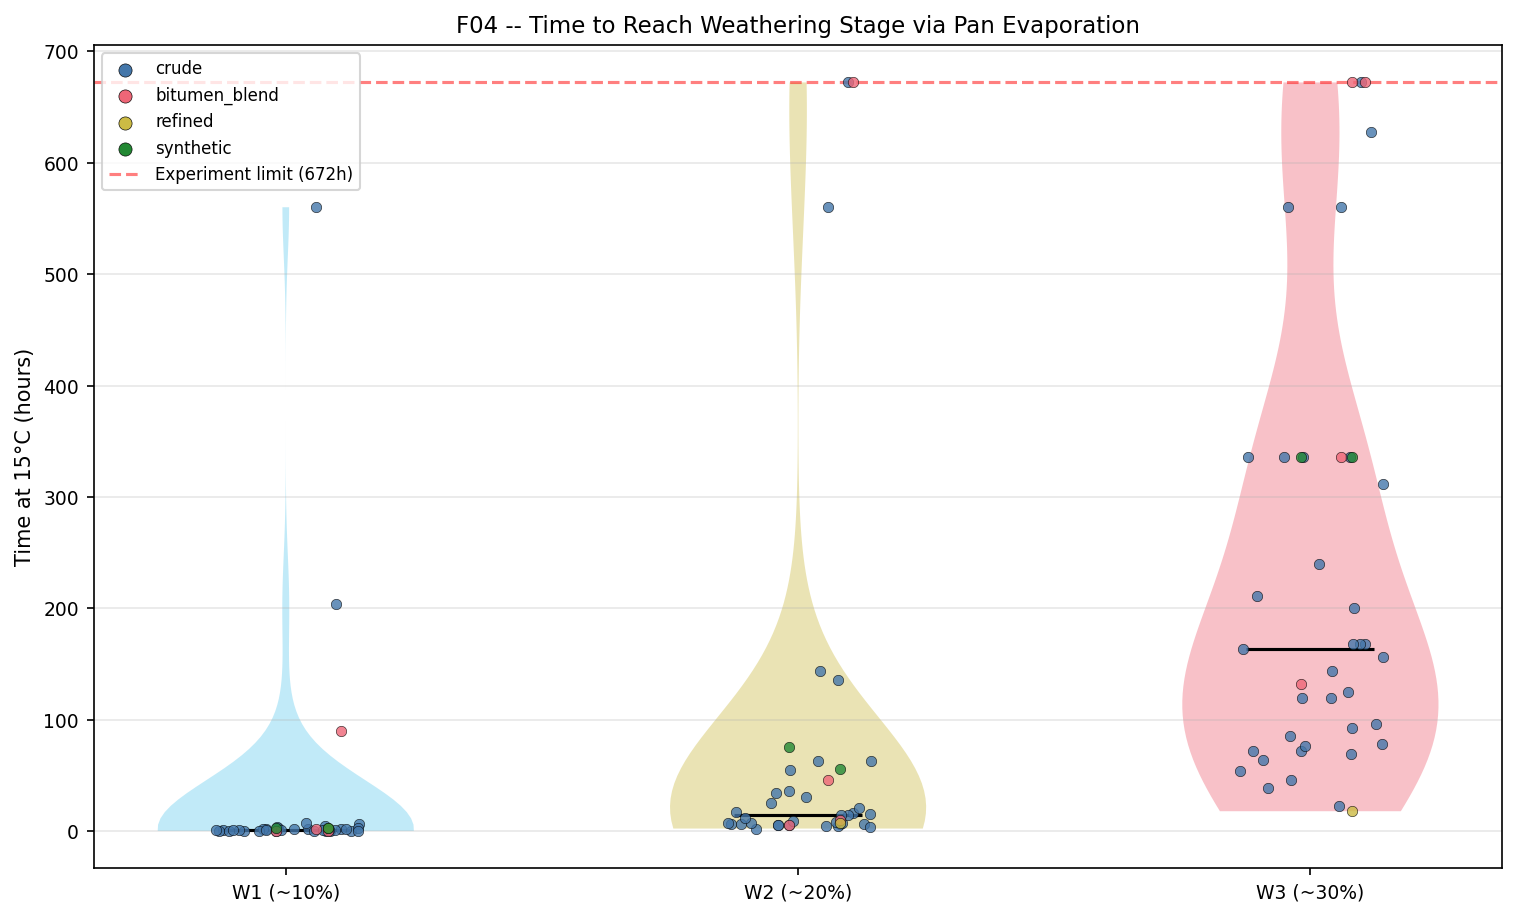

In [14]:
# F04 -- Violin/strip plot of time-to-stage
fig, ax = plt.subplots(figsize=(10, 6), constrained_layout=True)
positions = {'W1': 0, 'W2': 1, 'W3': 2}
for stage in ['W1', 'W2', 'W3']:
    sub = df_kin_stage[df_kin_stage['stage_code'] == stage]
    pos = positions[stage]
    parts = ax.violinplot(sub['time_hours'].values, positions=[pos],
                          showmedians=True, showextrema=False)
    for pc in parts['bodies']:
        pc.set_facecolor(STAGE_COLORS[stage]); pc.set_alpha(0.4)
    parts['cmedians'].set_color('black')
    for otype in OIL_TYPES_ML:
        otype_sub = sub[sub['oil_type'] == otype]
        if len(otype_sub) == 0: continue
        jitter = np.random.default_rng(42).uniform(-0.15, 0.15, len(otype_sub))
        ax.scatter(pos + jitter, otype_sub['time_hours'],
                  c=OILTYPE_COLORS[otype], s=25, edgecolors='k',
                  linewidth=0.3, alpha=0.8, zorder=5)
for otype in OIL_TYPES_ML:
    ax.scatter([], [], c=OILTYPE_COLORS[otype], s=40, edgecolors='k', linewidth=0.3, label=otype)
ax.axhline(ENDPOINT, color='red', linestyle='--', alpha=0.5, label=f'Experiment limit ({ENDPOINT:.0f}h)')
ax.set_xticks([0, 1, 2]); ax.set_xticklabels(['W1 (~10%)', 'W2 (~20%)', 'W3 (~30%)'])
ax.set_ylabel('Time at 15\u00b0C (hours)')
ax.set_title('F04 -- Time to Reach Weathering Stage via Pan Evaporation')
ax.legend(fontsize=8); ax.grid(alpha=0.3, axis='y')
fig_path = FIG_DIR / 'F04_time_to_stage_violin.png'
plt.savefig(fig_path, dpi=150, bbox_inches='tight')
plt.close('all')
display(Image(filename=str(fig_path)))

In [15]:
# C08 -- Time-to-stage table by oil type
print('Time-to-stage at 15\u00b0C by oil type (hours)\n')
print(f'{"Oil type":<16} {"W1 median (range)":<28} {"W2 median (range)":<28} {"W3 median (range)":<28}')
print('-' * 100)
for otype in OIL_TYPES_ML:
    parts = []
    for stage in ['W1', 'W2', 'W3']:
        sub = df_kin_stage[(df_kin_stage['stage_code'] == stage) &
                           (df_kin_stage['oil_type'] == otype)]
        if len(sub) == 0:
            parts.append('--')
        else:
            parts.append(f'{sub["time_hours"].median():.1f} ({sub["time_hours"].min():.1f} - {sub["time_hours"].max():.1f})')
    print(f'{otype:<16} {parts[0]:<28} {parts[1]:<28} {parts[2]:<28}')

Time-to-stage at 15°C by oil type (hours)

Oil type         W1 median (range)            W2 median (range)            W3 median (range)           
----------------------------------------------------------------------------------------------------
crude            1.3 (0.2 - 560.0)            13.0 (2.4 - 672.0)           150.0 (22.4 - 672.0)        
bitumen_blend    1.1 (0.4 - 90.0)             28.3 (5.9 - 672.0)           504.0 (132.0 - 672.0)       
refined          2.7 (2.7 - 2.7)              7.8 (7.8 - 7.8)              18.0 (18.0 - 18.0)          
synthetic        3.3 (3.3 - 3.3)              65.5 (55.6 - 75.4)           336.0 (336.0 - 336.0)       


## PART 4B — Temperature Amplification and Mass Loss Variability

Protocol endpoint comparison (rotary W3 vs pan 672h):
  Ratio mass_loss_80C / mass_loss_15C:
  Median: 0.97x
  Range: 0.34x - 3.31x
  n = 41 oils

Correlation 15°C vs 80°C mass loss: ρ = 0.600, p = 3.32e-05


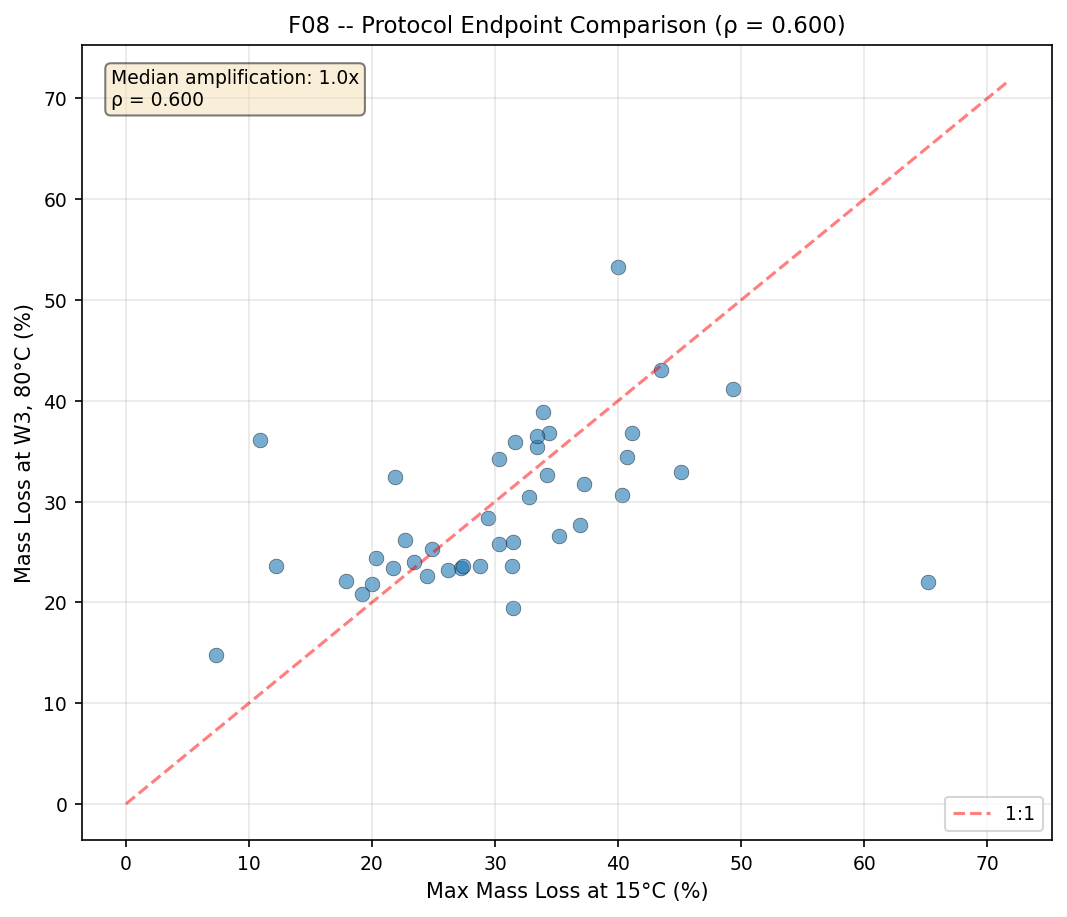


Interpretation: the similar endpoints (~1.0x) reflect experimental
design choices, NOT thermodynamic equivalence. The rotary protocol
at 80°C achieves in hours what pan evaporation at 15°C takes weeks.
Both experiments were stopped before equilibrium for most oils.


In [16]:
# B5 -- Protocol endpoint comparison: 15C pan (672h) vs 80C rotary (W3)
with get_conn() as conn:
    df_w3_mass = pd.read_sql("""
        SELECT oil_id, mass_loss_pct AS mass_loss_80C
        FROM oil_weathering_kinetics
        WHERE stage_code = 'W3'
    """, conn)

df_temp = df_kinetics.set_index('oil_id')[['max_mass_loss']].rename(
    columns={'max_mass_loss': 'mass_loss_15C'})
df_temp = df_temp.join(df_w3_mass.set_index('oil_id')).dropna()
df_temp['amplification'] = df_temp['mass_loss_80C'] / df_temp['mass_loss_15C'].replace(0, np.nan)
df_temp = df_temp.dropna(subset=['amplification'])

amp_median = df_temp['amplification'].median()
print(f'Protocol endpoint comparison (rotary W3 vs pan 672h):')
print(f'  Ratio mass_loss_80C / mass_loss_15C:')
print(f'  Median: {amp_median:.2f}x')
print(f'  Range: {df_temp["amplification"].min():.2f}x - {df_temp["amplification"].max():.2f}x')
print(f'  n = {len(df_temp)} oils')

rho_temp, p_temp = spearmanr(df_temp['mass_loss_15C'], df_temp['mass_loss_80C'])
print(f'\nCorrelation 15\u00b0C vs 80\u00b0C mass loss: \u03c1 = {rho_temp:.3f}, p = {p_temp:.2e}')

fig, ax = plt.subplots(figsize=(7, 6), constrained_layout=True)
ax.scatter(df_temp['mass_loss_15C'], df_temp['mass_loss_80C'],
           alpha=0.6, edgecolors='k', linewidth=0.3, s=50)
lims = [0, max(df_temp[['mass_loss_15C', 'mass_loss_80C']].max()) * 1.1]
ax.plot(lims, lims, 'r--', alpha=0.5, label='1:1')
ax.set_xlabel('Max Mass Loss at 15\u00b0C (%)'); ax.set_ylabel('Mass Loss at W3, 80\u00b0C (%)')
ax.set_title(f'F08 -- Protocol Endpoint Comparison (\u03c1 = {rho_temp:.3f})')
ax.text(0.03, 0.97, f'Median amplification: {amp_median:.1f}x\n\u03c1 = {rho_temp:.3f}',
        transform=ax.transAxes, fontsize=9, verticalalignment='top',
        bbox=dict(boxstyle='round', facecolor='wheat', alpha=0.5))
ax.legend(); ax.grid(alpha=0.3)
fig_path = FIG_DIR / 'F08_temperature_amplification.png'
plt.savefig(fig_path, dpi=150, bbox_inches='tight')
plt.close('all')
display(Image(filename=str(fig_path)))

print('\nInterpretation: the similar endpoints (~1.0x) reflect experimental')
print('design choices, NOT thermodynamic equivalence. The rotary protocol')
print('at 80\u00b0C achieves in hours what pan evaporation at 15\u00b0C takes weeks.')
print('Both experiments were stopped before equilibrium for most oils.')

Mass loss variability by stage (R17):
  W1: median=9.6%, range=[5.0, 20.3]%, CV=28.2%, n=41
  W2: median=19.1%, range=[9.9, 40.3]%, CV=28.6%, n=41
  W3: median=26.6%, range=[14.8, 53.3]%, CV=26.1%, n=41


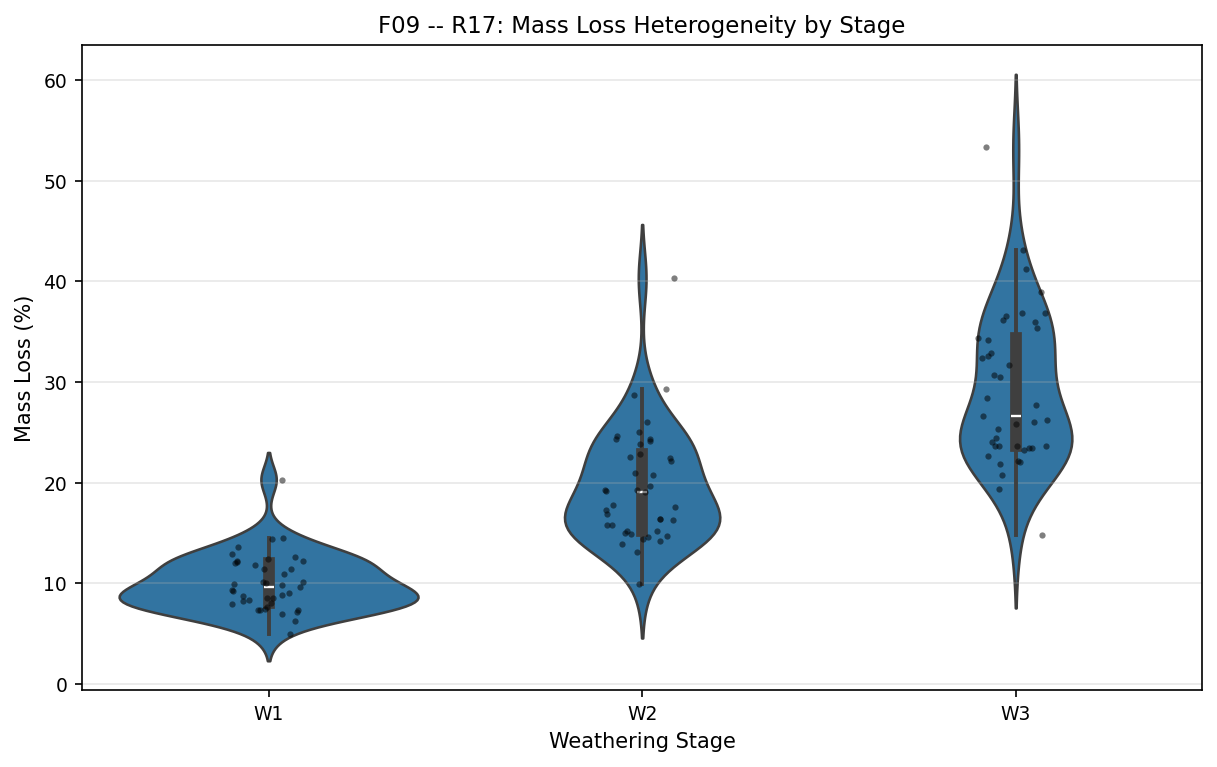

In [17]:
# B6 -- Per-stage mass loss variability (R17)
with get_conn() as conn:
    df_ml_stage = pd.read_sql("""
        SELECT k.oil_id, o.oil_type, k.stage_code, k.mass_loss_pct
        FROM oil_weathering_kinetics k
        JOIN oils o ON k.oil_id = o.oil_id
        WHERE o.include_in_analysis = 1
          AND k.stage_code IN ('W1', 'W2', 'W3')
    """, conn)

print('Mass loss variability by stage (R17):')
print('=' * 60)
cv_vals = {}
for stage in ['W1', 'W2', 'W3']:
    sub = df_ml_stage[df_ml_stage['stage_code'] == stage]['mass_loss_pct']
    cv = sub.std() / sub.mean() * 100
    cv_vals[stage] = cv
    print(f'  {stage}: median={sub.median():.1f}%, '
          f'range=[{sub.min():.1f}, {sub.max():.1f}]%, '
          f'CV={cv:.1f}%, n={len(sub)}')

fig, ax = plt.subplots(figsize=(8, 5), constrained_layout=True)
sns.violinplot(data=df_ml_stage, x='stage_code', y='mass_loss_pct',
               order=['W1', 'W2', 'W3'], ax=ax, inner='box')
sns.stripplot(data=df_ml_stage, x='stage_code', y='mass_loss_pct',
              order=['W1', 'W2', 'W3'], ax=ax, color='black', size=3, alpha=0.5)
ax.set_xlabel('Weathering Stage'); ax.set_ylabel('Mass Loss (%)')
ax.set_title('F09 -- R17: Mass Loss Heterogeneity by Stage')
ax.grid(alpha=0.3, axis='y')
fig_path = FIG_DIR / 'F09_mass_loss_variability.png'
plt.savefig(fig_path, dpi=150, bbox_inches='tight')
plt.close('all')
display(Image(filename=str(fig_path)))

## PART 5 — Forensic Time Mapping Preview

Representative oil: Deep Water Horizon Riser (oil_id=169)


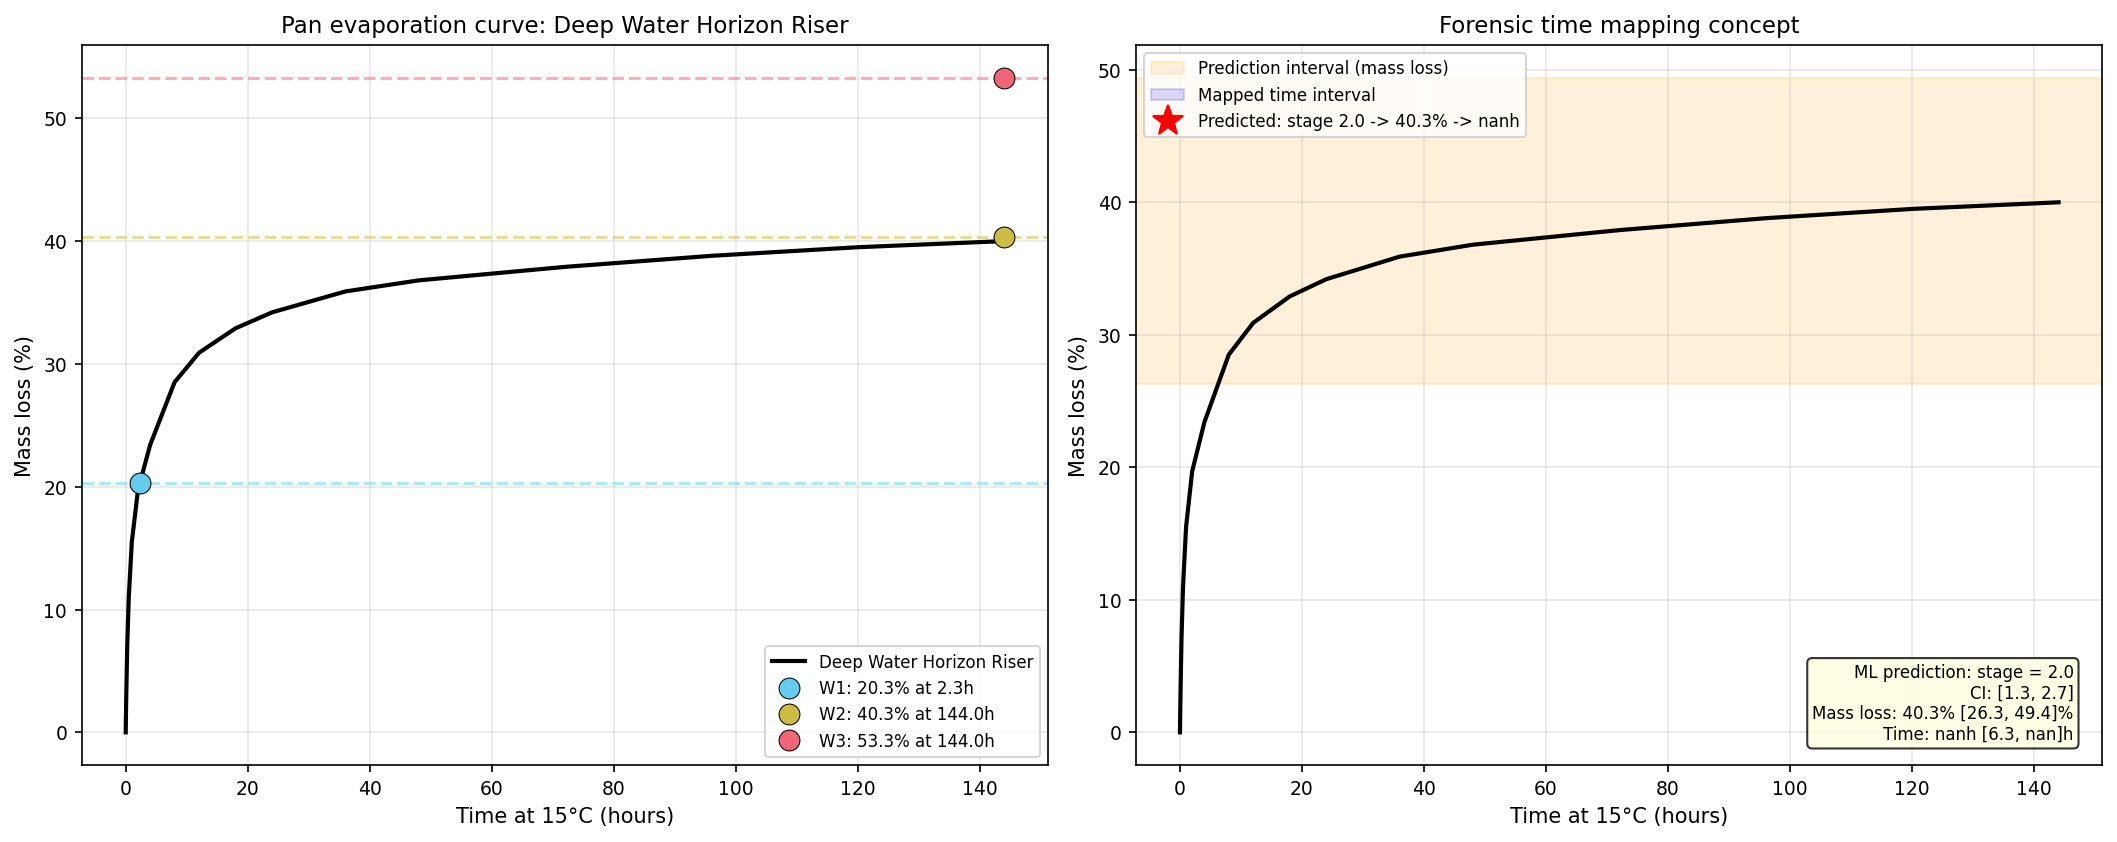


Forensic time mapping for Deep Water Horizon Riser:
  ML predicts stage 2.0 -> mass loss 40.3% -> ~nanh at 15°C
  With CI [1.3, 2.7]: time range [6.3, nan]h


In [18]:
# F05 -- Forensic time mapping concept for one representative crude
w3_crudes = df_kin_stage[(df_kin_stage['stage_code'] == 'W3') &
                          (df_kin_stage['oil_type'] == 'crude') &
                          (df_kin_stage['time_hours'] < (ENDPOINT - MARGIN)) &
                          (df_kin_stage['time_hours'] > 10)]
median_t = w3_crudes['time_hours'].median()
rep_idx = (w3_crudes['time_hours'] - median_t).abs().idxmin()
rep_oil_id = w3_crudes.loc[rep_idx, 'oil_id']
rep_oil_name = w3_crudes.loc[rep_idx, 'oil_name']
print(f'Representative oil: {rep_oil_name} (oil_id={rep_oil_id})')

rep_curve = df_pan[df_pan['oil_id'] == rep_oil_id].sort_values('time_hours')
rep_stages = df_kin_stage[df_kin_stage['oil_id'] == rep_oil_id]
stage_ml = dict(zip(rep_stages['stage_code'], rep_stages['mass_loss_pct']))
stage_time = dict(zip(rep_stages['stage_code'], rep_stages['time_hours']))

fig, axes = plt.subplots(1, 2, figsize=(14, 5.5), constrained_layout=True)

ax = axes[0]
ax.plot(rep_curve['time_hours'], rep_curve['mass_loss_pct'], 'k-', linewidth=2, label=rep_oil_name)
for stage in ['W1', 'W2', 'W3']:
    ax.axhline(stage_ml[stage], color=STAGE_COLORS[stage], linestyle='--', alpha=0.5)
    ax.plot(stage_time[stage], stage_ml[stage], 'o', color=STAGE_COLORS[stage], markersize=10,
            markeredgecolor='k', markeredgewidth=0.5, zorder=5,
            label=f'{stage}: {stage_ml[stage]:.1f}% at {stage_time[stage]:.1f}h')
ax.set_xlabel('Time at 15\u00b0C (hours)'); ax.set_ylabel('Mass loss (%)')
ax.set_title(f'Pan evaporation curve: {rep_oil_name}')
ax.legend(fontsize=8); ax.grid(alpha=0.3)

ax = axes[1]
ax.plot(rep_curve['time_hours'], rep_curve['mass_loss_pct'], 'k-', linewidth=2)
pred_stage = 2.0; ci_lo, ci_hi = 1.3, 2.7
stage_vals = {0: 0, 1: stage_ml['W1'], 2: stage_ml['W2'], 3: stage_ml['W3']}
stage_interp = interp1d(list(stage_vals.keys()), list(stage_vals.values()), fill_value='extrapolate')
ml_pred = float(stage_interp(pred_stage))
ml_lo = float(stage_interp(ci_lo)); ml_hi = float(stage_interp(ci_hi))
time_interp = interp1d(rep_curve['mass_loss_pct'].values, rep_curve['time_hours'].values,
                        bounds_error=False, fill_value=np.nan)
t_pred = float(time_interp(ml_pred))
t_lo = float(time_interp(ml_lo)); t_hi = float(time_interp(ml_hi))
ax.axhspan(ml_lo, ml_hi, alpha=0.15, color='orange', label='Prediction interval (mass loss)')
ax.axvspan(t_lo, t_hi, alpha=0.15, color='blue', label='Mapped time interval')
ax.plot(t_pred, ml_pred, '*', color='red', markersize=15, zorder=5,
        label=f'Predicted: stage {pred_stage:.1f} -> {ml_pred:.1f}% -> {t_pred:.1f}h')
ax.set_xlabel('Time at 15\u00b0C (hours)'); ax.set_ylabel('Mass loss (%)')
ax.set_title('Forensic time mapping concept')
ax.text(0.97, 0.03, f'ML prediction: stage = {pred_stage:.1f}\nCI: [{ci_lo:.1f}, {ci_hi:.1f}]\n'
        f'Mass loss: {ml_pred:.1f}% [{ml_lo:.1f}, {ml_hi:.1f}]%\nTime: {t_pred:.1f}h [{t_lo:.1f}, {t_hi:.1f}]h',
        transform=ax.transAxes, fontsize=8, verticalalignment='bottom', horizontalalignment='right',
        bbox=dict(boxstyle='round', facecolor='lightyellow', alpha=0.8))
ax.legend(fontsize=8, loc='upper left'); ax.grid(alpha=0.3)
fig_path = FIG_DIR / 'F05_forensic_time_mapping.png'
plt.savefig(fig_path, dpi=150, bbox_inches='tight')
plt.close('all')
display(Image(filename=str(fig_path)))
print(f'\nForensic time mapping for {rep_oil_name}:')
print(f'  ML predicts stage {pred_stage:.1f} -> mass loss {ml_pred:.1f}% -> ~{t_pred:.1f}h at 15\u00b0C')
print(f'  With CI [{ci_lo}, {ci_hi}]: time range [{t_lo:.1f}, {t_hi:.1f}]h')

## PART 6 — Curve Shape Classification and Model Connection

In [19]:
# B7 -- Curve shape classification (Fingas 2004)
def log_model(t, a):
    return a * np.log(t + 1)
def sqrt_model(t, a):
    return a * np.sqrt(t)

shape_results = []
for oil_id in df_pan['oil_id'].unique():
    oil_data = df_pan[df_pan['oil_id'] == oil_id].sort_values('time_hours')
    t = oil_data['time_hours'].values; ml = oil_data['mass_loss_pct'].values
    if len(t) < 5 or ml.max() < 1: continue
    mask = t > 0; t_pos, ml_pos = t[mask], ml[mask]
    try:
        popt, _ = curve_fit(log_model, t_pos, ml_pos, p0=[5])
        ss = np.sum((ml_pos - ml_pos.mean())**2)
        r2_log = 1 - np.sum((ml_pos - log_model(t_pos, *popt))**2) / ss if ss > 0 else np.nan
    except Exception: r2_log = np.nan
    try:
        popt, _ = curve_fit(sqrt_model, t_pos, ml_pos, p0=[1])
        ss = np.sum((ml_pos - ml_pos.mean())**2)
        r2_sqrt = 1 - np.sum((ml_pos - sqrt_model(t_pos, *popt))**2) / ss if ss > 0 else np.nan
    except Exception: r2_sqrt = np.nan
    shape_results.append({
        'A_log': popt[0] if r2_log is not np.nan else np.nan,
        'oil_id': oil_id, 'oil_type': oil_data['oil_type'].iloc[0],
        'r2_log': r2_log, 'r2_sqrt': r2_sqrt,
        'best_fit': 'logarithmic' if r2_log > r2_sqrt else 'square-root',
    })
df_shape = pd.DataFrame(shape_results)
print('Curve shape classification (Fingas 2004):')
print(df_shape.groupby(['oil_type', 'best_fit']).size().unstack(fill_value=0))
print(f'\nMean R2 -- log: {df_shape["r2_log"].mean():.3f}, sqrt: {df_shape["r2_sqrt"].mean():.3f}')

sqrt_crudes = df_shape[(df_shape['oil_type'] == 'crude') & (df_shape['best_fit'] == 'square-root')]
if len(sqrt_crudes) > 0:
    print(f'\nSquare-root crude oils ({len(sqrt_crudes)}):')
    for _, row in sqrt_crudes.iterrows():
        oname = df_kinetics[df_kinetics['oil_id'] == row['oil_id']]['oil_name'].iloc[0]
        print(f'  {oname}: R2_log={row["r2_log"]:.3f}, R2_sqrt={row["r2_sqrt"]:.3f}')
    print('  These oils may be compositionally unusual (condensate-like).')

# Compare linear EER with log coefficient A
df_shape_kin = df_shape.merge(df_kinetics[['oil_id', 'initial_rate']], on='oil_id')
df_shape_kin = df_shape_kin.dropna(subset=['A_log', 'initial_rate'])
if len(df_shape_kin) > 10:
    rho_A, p_A = spearmanr(df_shape_kin['initial_rate'], df_shape_kin['A_log'])
    print(f'\nLinear EER vs log coefficient A: \u03c1 = {rho_A:.3f}, p = {p_A:.2e} (n={len(df_shape_kin)})')
    if abs(rho_A) > 0.9:
        print('  Strong correlation: linear EER is an acceptable approximation.')
    else:
        print('  Moderate correlation: interpret with caution.')

Curve shape classification (Fingas 2004):
best_fit       logarithmic  square-root
oil_type                               
bitumen_blend            4            0
crude                   32            2
refined                  1            0
synthetic                2            0

Mean R2 -- log: 0.857, sqrt: 0.352

Square-root crude oils (2):
  Alaska North Slope [2012]: R2_log=0.897, R2_sqrt=0.977
  Husky Energy SGS: R2_log=0.807, R2_sqrt=0.969
  These oils may be compositionally unusual (condensate-like).

Linear EER vs log coefficient A: ρ = 0.542, p = 2.54e-04 (n=41)
  Moderate correlation: interpret with caution.


In [20]:
# B3 -- Kinetic parameters vs LOOO MAE per oil (conditional on NB04)
with get_conn() as conn:
    n_looo = conn.execute('SELECT COUNT(*) FROM looo_predictions').fetchone()[0]

if n_looo > 0:
    with get_conn() as conn:
        df_mae = pd.read_sql("""
            SELECT oil_id, AVG(abs_error) AS oil_mae
            FROM looo_predictions
            GROUP BY oil_id
        """, conn)
    df_mae_kin = df_mae.set_index('oil_id').join(
        df_kinetics.set_index('oil_id')).dropna(subset=['initial_rate', 'oil_mae'])
    if len(df_mae_kin) > 10:
        rho_ier_mae, p_ier_mae = spearmanr(df_mae_kin['initial_rate'], df_mae_kin['oil_mae'])
        rho_ml_mae, p_ml_mae = spearmanr(df_mae_kin['max_mass_loss'], df_mae_kin['oil_mae'])
        print(f'Kinetics vs model error (n={len(df_mae_kin)}):')
        print(f'  IER vs MAE:    \u03c1 = {rho_ier_mae:.3f}, p = {p_ier_mae:.2e}')
        print(f'  ML_max vs MAE: \u03c1 = {rho_ml_mae:.3f}, p = {p_ml_mae:.2e}')
        fig, axes = plt.subplots(1, 2, figsize=(12, 5), constrained_layout=True)
        axes[0].scatter(df_mae_kin['initial_rate'], df_mae_kin['oil_mae'], alpha=0.6, edgecolors='k', linewidth=0.3)
        axes[0].set_xlabel('Initial Evaporation Rate (%/h)'); axes[0].set_ylabel('Oil MAE')
        axes[0].set_title(f'IER vs MAE (\u03c1 = {rho_ier_mae:.3f})'); axes[0].grid(alpha=0.3)
        axes[1].scatter(df_mae_kin['max_mass_loss'], df_mae_kin['oil_mae'], alpha=0.6, edgecolors='k', linewidth=0.3)
        axes[1].set_xlabel('Max Mass Loss at 672h (%)'); axes[1].set_ylabel('Oil MAE')
        axes[1].set_title(f'ML_max vs MAE (\u03c1 = {rho_ml_mae:.3f})'); axes[1].grid(alpha=0.3)
        fig_path = FIG_DIR / 'F07_kinetics_vs_mae.png'
        plt.savefig(fig_path, dpi=150, bbox_inches='tight'); plt.close('all')
        display(Image(filename=str(fig_path)))
    else:
        print('Insufficient LOOO data for correlation')
else:
    print('LOOO predictions table is empty (NB04 not yet run).')
    print('B3 analysis (kinetics vs model MAE) will be available after running the ML pipeline.')

LOOO predictions table is empty (NB04 not yet run).
B3 analysis (kinetics vs model MAE) will be available after running the ML pipeline.


In [21]:
# Fair comparison: all correlations on the same oil set
# Deduplicate each predictor to 1 value per oil
vf = frac_volatile.drop_duplicates('oil_id').set_index('oil_id')['frac_volatile_pct']
ucm = df_ucm.drop_duplicates('oil_id').set_index('oil_id')['ucm_fraction']
api = df_api.drop_duplicates('oil_id').set_index('oil_id')['api_gravity'].dropna()

common_ids = set(df_kinetics['oil_id']) & set(vf.index) & set(ucm.index) & set(api.index)
print(f'Common oil subset for fair comparison: {len(common_ids)} oils\n')
print(f'{"Predictor":<25s} {"vs EER rho":>10s} {"p":>10s} {"vs MLmax rho":>12s} {"p":>10s}')
print("-" * 70)

kin_c = df_kinetics[df_kinetics['oil_id'].isin(common_ids)].set_index('oil_id')

for name, series in [('Volatile fraction', vf), ('UCM fraction', ucm), ('API gravity', api)]:
    common_idx = kin_c.index.intersection(series.index)
    vals = series.loc[common_idx]
    sub = kin_c.loc[common_idx]
    if len(sub) > 10:
        r1, p1 = spearmanr(vals, sub['initial_rate'])
        r2, p2 = spearmanr(vals, sub['max_mass_loss'])
        print(f'{name:<25s} {r1:>+10.3f} {p1:>10.2e} {r2:>+12.3f} {p2:>10.2e}')
    else:
        print(f'{name:<25s}  insufficient data (n={len(sub)})')

Common oil subset for fair comparison: 25 oils

Predictor                 vs EER rho          p vs MLmax rho          p
----------------------------------------------------------------------
Volatile fraction             +0.090   6.69e-01       +0.044   8.35e-01
UCM fraction                  -0.196   3.47e-01       -0.368   7.06e-02
API gravity                   +0.492   1.26e-02       +0.821   5.09e-07


## PART 7 — Summary

In [22]:
# Summary
missing_names = ', '.join(missing['oil_name'].values[:5])
if len(missing) > 5:
    missing_names += '...'

print('NB03d SUMMARY (FINAL)')
print('=' * 50)
print(f'Pan evaporation data: {n_oils} oils, {n_times} time points (0-672h at 15\u00b0C)')
print(f'Kinetic parameters: EER, ML_max, t_half for {len(df_kinetics)} oils')
print(f'Missing oils (no pan data): {len(missing)} -- [{missing_names}]')
print(f'ML-qualified oils with pan data: {len(ml_with_pan)}/{len(ml_oils)}')
print()
print('Cross-experiment validation:')
print(f'  Volatile fraction vs EER:    \u03c1 = {rho_ier:.3f} (p = {p_ier:.2e}) -- NULL')
print(f'  Volatile fraction vs ML_max: \u03c1 = {rho_ml:.3f} (p = {p_ml:.2e}) -- NULL')
print(f'  -> GC-MS resolved compounds (15-34% of oil mass) decouple from')
print(f'     bulk evaporation (dominated by UCM, 66-85% of mass)')
print()
print(f'  UCM fraction vs EER:    \u03c1 = {rho_ucm_ier:.3f} (p = {p_ucm_ier:.2e})')
print(f'  UCM fraction vs ML_max: \u03c1 = {rho_ucm_ml:.3f} (p = {p_ucm_ml:.2e})')
print()
print(f'  API gravity vs EER:    \u03c1 = {rho_api:.3f} (p = {p_api:.2e}, n={len(df_api_merged)})')
print(f'  API gravity vs ML_max: \u03c1 = {rho_api_ml:.3f} (p = {p_api_ml:.2e})')
print()
print('Time-to-stage at 15\u00b0C (corrected, endpoint excluded):')
for stage in ['W1', 'W2', 'W3']:
    sub = df_kin_stage[df_kin_stage['stage_code'] == stage]
    med = sub['time_hours'].median()
    lo = sub['time_hours'].min(); hi = sub['time_hours'].max()
    n_reach = (sub['time_hours'] < (ENDPOINT - MARGIN)).sum()
    print(f'  {stage}: median = {med:.1f}h (range {lo:.1f}-{hi:.1f}h), {n_reach}/{len(sub)} reach within 672h')
print()
print(f'Protocol endpoint comparison (80\u00b0C/15\u00b0C): median ratio = {amp_median:.2f}x')
print(f'  (reflects experimental design, not thermodynamic equivalence)')
print()
print(f'Mass loss CV: W1={cv_vals["W1"]:.0f}%, W2={cv_vals["W2"]:.0f}%, W3={cv_vals["W3"]:.0f}%')
print()
r2_log_mean = df_shape['r2_log'].mean()
r2_sqrt_mean = df_shape['r2_sqrt'].mean()
n_log = (df_shape['best_fit'] == 'logarithmic').sum()
n_sqrt = (df_shape['best_fit'] == 'square-root').sum()
print(f'Curve shape: {n_log} logarithmic, {n_sqrt} square-root (mean R2 log={r2_log_mean:.3f}, sqrt={r2_sqrt_mean:.3f})')
print()
print(f'Figures saved to: {FIG_DIR}')
print()
print('Key insight: GC-MS fingerprints predict weathering STATE but not')
print('weathering RATE. Physical properties (API, density) predict rate.')
print('The ML model succeeds because resolved compounds undergo systematic')
print('changes correlated with total mass loss, even though they represent')
print('only a fraction of the evaporating material.')
print()
print('Note: kinetic parameters (EER, ML_max, t_half) are descriptive only.')
print('They are NOT used as ML features (D25: describes the oil, not the weathering state).')

NB03d SUMMARY (FINAL)
Pan evaporation data: 41 oils, 29 time points (0-672h at 15°C)
Kinetic parameters: EER, ML_max, t_half for 41 oils
Missing oils (no pan data): 21 -- [Alberta Sweet Mixed Blend #4, Cold Lake Blend Summer [2014], Cold Lake Blend Winter [2015], Cold Lake Blend Winter [2018], Cold Lake Blend Winter [2019]...]
ML-qualified oils with pan data: 37/53

Cross-experiment validation:
  Volatile fraction vs EER:    ρ = -0.009 (p = 9.55e-01) -- NULL
  Volatile fraction vs ML_max: ρ = 0.018 (p = 9.16e-01) -- NULL
  -> GC-MS resolved compounds (15-34% of oil mass) decouple from
     bulk evaporation (dominated by UCM, 66-85% of mass)

  UCM fraction vs EER:    ρ = -0.280 (p = 1.58e-01)
  UCM fraction vs ML_max: ρ = -0.422 (p = 2.83e-02)

  API gravity vs EER:    ρ = 0.477 (p = 2.14e-03, n=39)
  API gravity vs ML_max: ρ = 0.875 (p = 3.45e-13)

Time-to-stage at 15°C (corrected, endpoint excluded):
  W1: median = 1.4h (range 0.2-560.0h), 41/41 reach within 672h
  W2: median = 14.5h

## PART 8 — Robustness Checks

Sensitivity analyses to stress-test the correlations reported above.
Each check targets a specific concern about leverage, censoring, or sample composition.

In [23]:
# R01 -- API gravity vs kinetics: crude-only subset
# Purpose: test if the API vs ML_max correlation is driven by between-type
# leverage (refined oil at high API + high ML_max, bitumen blends at low end)
crude_merged = df_api_merged[df_api_merged['oil_type'] == 'crude']
if len(crude_merged) > 10:
    rho_crude_ier, p_crude_ier = spearmanr(crude_merged['api_gravity'],
                                            crude_merged['initial_rate'])
    rho_crude_ml, p_crude_ml = spearmanr(crude_merged['api_gravity'],
                                          crude_merged['max_mass_loss'])
    print(f'API gravity vs kinetics \u2014 CRUDE ONLY (n={len(crude_merged)}):')
    print(f'  vs EER:    \u03c1 = {rho_crude_ier:.3f}, p = {p_crude_ier:.2e}')
    print(f'  vs ML_max: \u03c1 = {rho_crude_ml:.3f}, p = {p_crude_ml:.2e}')
    print()
    print(f'Compare with all oil types (n={len(df_api_merged)}):')
    print(f'  vs EER:    \u03c1 = {rho_api:.3f}')
    print(f'  vs ML_max: \u03c1 = {rho_api_ml:.3f}')
    print()
    if rho_crude_ml < 0.6:
        print('\u26a0\ufe0f Correlation drops below 0.6 for crudes alone.')
        print('The strong correlation was partly driven by between-type variation.')
        print('Report BOTH values in thesis.')
    else:
        print('\u2705 Correlation remains strong for crudes alone.')
        print('API gravity predicts evaporation within crude oils, not just between types.')
else:
    print(f'Insufficient crude oils with API data (n={len(crude_merged)})')

API gravity vs kinetics — CRUDE ONLY (n=32):
  vs EER:    ρ = 0.645, p = 6.71e-05
  vs ML_max: ρ = 0.848, p = 9.20e-10

Compare with all oil types (n=39):
  vs EER:    ρ = 0.477
  vs ML_max: ρ = 0.875

✅ Correlation remains strong for crudes alone.
API gravity predicts evaporation within crude oils, not just between types.


In [24]:
# R02 -- Add n-C9 to fair comparison table
# Purpose: is n-C9 a better predictor than the volatile fraction sum?
with get_conn() as conn:
    df_nc9 = pd.read_sql("""
        SELECT m.oil_id, m.value_raw AS nc9_value
        FROM measurements m
        JOIN compounds c ON m.compound_id = c.compound_id
        JOIN oils o ON m.oil_id = o.oil_id
        WHERE c.compound_name LIKE 'n-C9%'
          AND m.stage_code = 'W0'
          AND o.include_in_analysis = 1
          AND m.value_raw > 0
    """, conn)

nc9_series = df_nc9.drop_duplicates('oil_id').set_index('oil_id')['nc9_value']

# Recompute on common subset that includes n-C9
common_ids_nc9 = common_ids & set(nc9_series.index)
print(f'Common subset with n-C9: {len(common_ids_nc9)} oils\n')

kin_nc9 = df_kinetics[df_kinetics['oil_id'].isin(common_ids_nc9)].set_index('oil_id')
nc9_common = nc9_series.reindex(kin_nc9.index).dropna()
kin_nc9 = kin_nc9.loc[nc9_common.index]

r_nc9_eer, p_nc9_eer = spearmanr(nc9_common, kin_nc9['initial_rate'])
r_nc9_ml, p_nc9_ml = spearmanr(nc9_common, kin_nc9['max_mass_loss'])

# Print extended fair comparison table
print(f"{'Predictor':<25s} {'vs EER rho':>10s} {'p':>10s} {'vs MLmax rho':>12s} {'p':>10s}")
print("-" * 70)

kin_c_nc9 = df_kinetics[df_kinetics['oil_id'].isin(common_ids_nc9)].set_index('oil_id')
for name, series in [('Volatile fraction', vf), ('UCM fraction', ucm),
                      ('API gravity', api), ('n-C9 concentration', nc9_series)]:
    common_idx = kin_c_nc9.index.intersection(series.index)
    vals = series.loc[common_idx]
    sub = kin_c_nc9.loc[common_idx]
    if len(sub) > 10:
        r1, p1 = spearmanr(vals, sub['initial_rate'])
        r2, p2 = spearmanr(vals, sub['max_mass_loss'])
        print(f'{name:<25s} {r1:>+10.3f} {p1:>10.2e} {r2:>+12.3f} {p2:>10.2e}')
    else:
        print(f'{name:<25s}  insufficient data (n={len(sub)})')

Common subset with n-C9: 24 oils

Predictor                 vs EER rho          p vs MLmax rho          p
----------------------------------------------------------------------
Volatile fraction             +0.025   9.07e-01       +0.010   9.61e-01
UCM fraction                  -0.189   3.78e-01       -0.361   8.33e-02
API gravity                   +0.487   1.57e-02       +0.826   6.72e-07
n-C9 concentration            +0.322   1.25e-01       +0.471   2.01e-02


### Note: GC-MS Signal vs Mass

The volatile fraction is computed from semi-quantitative GC-MS peak areas
(relative, not absolute mass). Response factors differ between compound classes,
so "volatile fraction = 30%" means 30% of **GC-MS signal** from volatile
compounds, not 30% of **oil mass**. This signal-vs-mass mismatch may contribute
to the null correlation with mass-based pan evaporation measurements, alongside
the UCM dilution effect discussed above.

In [25]:
# R03 -- API correlation excluding 672h boundary oils
# Purpose: test whether oils at the experiment endpoint (truncated ML_max)
# inflate the correlation
boundary_oils = df_kin_stage[
    (df_kin_stage['time_hours'] >= (ENDPOINT - MARGIN)) &
    (df_kin_stage['stage_code'] == 'W3')
]['oil_id'].unique()
print(f'Boundary oils (W3 at ~672h): {len(boundary_oils)}')

non_boundary = df_api_merged[~df_api_merged['oil_id'].isin(boundary_oils)]
if len(non_boundary) > 10:
    rho_nb_ier, p_nb_ier = spearmanr(non_boundary['api_gravity'],
                                      non_boundary['initial_rate'])
    rho_nb_ml, p_nb_ml = spearmanr(non_boundary['api_gravity'],
                                    non_boundary['max_mass_loss'])
    print(f'API vs kinetics excluding boundary oils (n={len(non_boundary)}):')
    print(f'  vs EER:    \u03c1 = {rho_nb_ier:.3f}, p = {p_nb_ier:.2e}')
    print(f'  vs ML_max: \u03c1 = {rho_nb_ml:.3f}, p = {p_nb_ml:.2e}')
    print()
    print(f'Original (n={len(df_api_merged)}):')
    print(f'  vs EER:    \u03c1 = {rho_api:.3f}')
    print(f'  vs ML_max: \u03c1 = {rho_api_ml:.3f}')
    print()
    delta_ml = abs(rho_api_ml - rho_nb_ml)
    delta_ier = abs(rho_api - rho_nb_ier)
    if delta_ml > 0.05:
        print(f'\u26a0\ufe0f ML_max correlation changes by {delta_ml:.3f} \u2014 boundary oils influential')
    else:
        print(f'\u2705 ML_max correlation robust (\u0394\u03c1 = {delta_ml:.3f})')
    if delta_ier > 0.05:
        print(f'\u26a0\ufe0f EER correlation changes by {delta_ier:.3f} \u2014 boundary oils influential')
    else:
        print(f'\u2705 EER correlation robust (\u0394\u03c1 = {delta_ier:.3f})')
else:
    print(f'Insufficient non-boundary oils (n={len(non_boundary)})')

Boundary oils (W3 at ~672h): 3
API vs kinetics excluding boundary oils (n=36):
  vs EER:    ρ = 0.485, p = 2.73e-03
  vs ML_max: ρ = 0.865, p = 1.06e-11

Original (n=39):
  vs EER:    ρ = 0.477
  vs ML_max: ρ = 0.875

✅ ML_max correlation robust (Δρ = 0.010)
✅ EER correlation robust (Δρ = 0.008)


In [26]:
# R04 -- UCM fragility: identify oils lost from n=27 to common subset
# Purpose: the UCM correlation weakens on the common subset. Which oils are lost?
ucm_oil_ids = set(df_ucm_kin.index)
ucm_not_in_common = ucm_oil_ids - common_ids

print(f'UCM oils NOT in common subset ({len(ucm_not_in_common)}):')
for oid in sorted(ucm_not_in_common):
    with get_conn() as conn:
        info = conn.execute(
            'SELECT oil_name, oil_type FROM oils WHERE oil_id = ?', (oid,)
        ).fetchone()
    if info:
        ucm_val = df_ucm_kin.loc[oid, 'ucm_fraction'] if oid in df_ucm_kin.index else np.nan
        kin_row = df_kinetics[df_kinetics['oil_id'] == oid]
        ml_val = kin_row['max_mass_loss'].values[0] if len(kin_row) > 0 else np.nan
        print(f'  {info[0]} ({info[1]}): UCM={ucm_val:.3f}, ML_max={ml_val:.1f}%')

# Sensitivity: remove most extreme UCM oil from n=27 set
print('\nSensitivity: leave-one-out on extreme UCM oils (n=27 set):')
ucm_sorted = df_ucm_kin.sort_values('ucm_fraction')
for remove_idx, label in [(0, 'lowest UCM'), (-1, 'highest UCM')]:
    if remove_idx == 0:
        reduced = ucm_sorted.iloc[1:]
    else:
        reduced = ucm_sorted.iloc[:-1]
    rho_r, p_r = spearmanr(reduced['ucm_fraction'], reduced['max_mass_loss'])
    removed_oil = ucm_sorted.iloc[remove_idx]
    print(f'  Remove {label} ({removed_oil.name}, UCM={removed_oil["ucm_fraction"]:.3f}): '
          f'\u03c1 = {rho_r:.3f}, p = {p_r:.3f} (n={len(reduced)})')

print(f'\nOriginal n={len(df_ucm_kin)}: \u03c1 = {rho_ucm_ml:.3f}')
print('Interpretation: UCM correlation is a marginal trend, sensitive to sample composition.')

UCM oils NOT in common subset (2):
  Arabian Heavy [2004] (crude): UCM=0.760, ML_max=26.2%
  Deep Water Horizon Riser (crude): UCM=0.560, ML_max=40.0%

Sensitivity: leave-one-out on extreme UCM oils (n=27 set):
  Remove lowest UCM (169, UCM=0.560): ρ = -0.366, p = 0.066 (n=26)
  Remove highest UCM (189, UCM=0.930): ρ = -0.353, p = 0.077 (n=26)

Original n=27: ρ = -0.422
Interpretation: UCM correlation is a marginal trend, sensitive to sample composition.


In [27]:
# R05 -- Robustness checks summary
print('ROBUSTNESS CHECKS SUMMARY')
print('=' * 50)

# Check 1
if len(crude_merged) > 10:
    print(f'  API vs ML_max crude-only:   \u03c1 = {rho_crude_ml:.3f} (all types: {rho_api_ml:.3f})')
    print(f'  API vs EER crude-only:      \u03c1 = {rho_crude_ier:.3f} (all types: {rho_api:.3f})')

# Check 2
print(f'  n-C9 vs EER (common subset): \u03c1 = {r_nc9_eer:+.3f} (p={p_nc9_eer:.2e})')
print(f'  n-C9 vs ML_max:              \u03c1 = {r_nc9_ml:+.3f} (p={p_nc9_ml:.2e})')

# Check 3
print(f'  Volatile fraction units: signal-based, not mass-based (noted)')

# Check 4
if len(non_boundary) > 10:
    print(f'  API vs ML_max no boundary:  \u03c1 = {rho_nb_ml:.3f} (all: {rho_api_ml:.3f})')

# Check 5
print(f'  UCM vs ML_max: sensitive to \u00b11 oil (report as marginal trend)')
print()
print('All checks complete. See cells R01-R04 above for details.')

ROBUSTNESS CHECKS SUMMARY
  API vs ML_max crude-only:   ρ = 0.848 (all types: 0.875)
  API vs EER crude-only:      ρ = 0.645 (all types: 0.477)
  n-C9 vs EER (common subset): ρ = +0.322 (p=1.25e-01)
  n-C9 vs ML_max:              ρ = +0.471 (p=2.01e-02)
  Volatile fraction units: signal-based, not mass-based (noted)
  API vs ML_max no boundary:  ρ = 0.865 (all: 0.875)
  UCM vs ML_max: sensitive to ±1 oil (report as marginal trend)

All checks complete. See cells R01-R04 above for details.
